## 라이브러리 임포트

In [ ]:
!pip install -q lightgbm catboost xgboost optuna shap

# [CONFIG]
N_SPLITS = 5    # K-Fold 수

# [CONFIG] 타깃 변환 모드 선택
#   "log1p"  : y = log1p(view_count),  inverse = expm1(pred)
#   "boxcox" : y = boxcox(view_count + 1) with fitted lambda,
#              inverse = clip(inv_boxcox(pred, lambda) - 1, 0, None)
TARGET_MODE = "log1p"  # "log1p" | "boxcox"

# 라이브러리 임포트

import sys
from pathlib import Path
# 피처엔지니어링 모듈(JNeighbors, FeatureEngineering) 로드 경로: 03_FeatureEngineering
sys.path.insert(0, str(Path("../03_FeatureEngineering").resolve()))

import FeatureEngineering as fe
from JNeighbors import make_jnn_features

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterSciNotation, FuncFormatter

import shap
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 판다스 기본설정
pd.set_option('display.max_columns', None)

# 공통 스타일 적용 (plot_style.py)
import plot_style
plot_style.apply()

# 공통 포맷터
fmt_man = FuncFormatter(lambda x, _: f"{x/10000:.0f}만")

from sklearn.base import clone
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import OrdinalEncoder
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_log_error, mean_absolute_percentage_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor

# GBM 계열
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

# TargetTransform: log1p / box-cox 통합 변환기
class TargetTransform:
    """조회수 타깃 변환기. TARGET_MODE에 따라 log1p 또는 Box-Cox로 전환.
    Box-Cox는 train에서 fit한 lambda를 test에도 재사용 (누수 방지)."""

    def __init__(self, mode):
        assert mode in ("log1p", "boxcox"), f"unknown TARGET_MODE: {mode}"
        self.mode = mode
        self.state = None  # box-cox lambda

    def fit_transform(self, y):
        """train에서 호출. 변환된 y 반환, state 저장."""
        if self.mode == "log1p":
            return np.log1p(y)
        y_bc, lam = boxcox(y + 1)
        self.state = lam
        return y_bc

    def transform(self, y):
        """test에서 호출. fit된 state 사용."""
        if self.mode == "log1p":
            return np.log1p(y)
        assert self.state is not None, "boxcox mode: fit_transform을 먼저 호출"
        return boxcox(y + 1, lmbda=self.state)

    def inverse(self, y_t):
        """예측/타깃 -> view_count 스케일."""
        if self.mode == "log1p":
            return np.expm1(y_t)
        assert self.state is not None, "boxcox mode: fit_transform을 먼저 호출"
        return np.clip(inv_boxcox(y_t, self.state) - 1, 0, None)


tt = TargetTransform(TARGET_MODE)
print(f"TargetTransform: mode={TARGET_MODE}")

## 데이터 로드

In [2]:
# 데이터 로드
train = pd.read_csv("train.csv", sep="\x01")
test = pd.read_csv("test.csv", sep="\x01")

print(f"Train: {train.shape} | Test: {test.shape}")

Train: (3285, 99) | Test: (865, 99)


In [3]:
# Gemini 채널 피처 병합
CHANNEL_GEMINI_PATH = "channel_gemini.csv"
df_channel = pd.read_csv(CHANNEL_GEMINI_PATH)

# 필요한 컬럼만 선택
merge_cols = ["channel_id", "worldview_type", "affiliated_group", "concept_age_group_est"]
df_channel = df_channel[merge_cols]

# train/test에 병합 → 소속사 이진화 → 원본 컬럼 제거
train = train.merge(df_channel, on="channel_id", how="left")
test = test.merge(df_channel, on="channel_id", how="left")
train = fe.add_has_affiliated_group(train)
test = fe.add_has_affiliated_group(test)
train = train.drop(columns=["affiliated_group"])
test = test.drop(columns=["affiliated_group"])

print(f"채널 Gemini 피처 병합 완료")
print(f"Train: {train.shape} | Test: {test.shape}")
print(f"\nworldview_type 분포:\n{train['worldview_type'].value_counts().to_string()}")
print(f"\nconcept_age_group_est 분포:\n{train['concept_age_group_est'].value_counts().to_string()}")
print(f"\nhas_affiliated_group 분포:\n{train['has_affiliated_group'].value_counts().to_string()}")

채널 Gemini 피처 병합 완료
Train: (3285, 102) | Test: (865, 102)

worldview_type 분포:
worldview_type
판타지    1193
없음      741
현대      633
동물      260
기타      243
신화      132
SF       83

concept_age_group_est 분포:
concept_age_group_est
20대        2291
10대         764
30대이상       134
unknown      96

has_affiliated_group 분포:
has_affiliated_group
1    2887
0     398


## 파생변수 생성

In [4]:
# 파생변수 일괄 적용
train = fe.run_feature_engineering(train)
test = fe.run_feature_engineering(test)

# JNN 피처: JNN_COLS에서 필요한 target_cols, agg_funcs 자동 파싱
jnn_target_cols, jnn_agg_func_names = fe.get_jnn_params()

# JNN 피처: train에서 생성 (과거 N개 미만 행 제거)
train = make_jnn_features(train, N=15, drop_insufficient=True,
                          target_cols=jnn_target_cols, agg_funcs=jnn_agg_func_names)

# 채널단위 집계 피처: train 값으로 test 덮어쓰기
test = fe.map_channel_features(train, test)

# JNN 피처: train의 채널별 마지막 값으로 test 덮어쓰기
test = fe.map_jnn_features(train, test)

# video_order: train에서 이어서 번호 매기기
test = fe.map_video_order(train, test)

# 모델링용 컬럼만 선택
train = fe.select_columns(train)
test = fe.select_columns(test)

# 채널단위 수치 피처 구간화 (등빈도 5분위, train 기준 bins → test 적용)
train, test = fe.bin_channel_features(train, test, q=5)

print(f"Train: {train.shape} | Test: {test.shape}")
print(f"\n컬럼: {list(train.columns)}")
train.head()

[map_jnn_features] train에 없는 채널 68행 제거 (865 → 797)
Train: (2045, 18) | Test: (797, 18)

컬럼: ['video_id', 'channel_id', 'view_count', 'like_count', 'tag_count', 'f0_cv', 'worldview_type', 'concept_age_group_est', 'chat_interaction_frequency', 'thumbnail_text_provocativeness_level', 'thumb_character_total_character_count', 'content_category_primary_genre', 'content_category_secondary_genre', 'collaboration_collaboration_format', 'surprise_factor_content_surprise_level', 'vtuber_features_score', 'vtuber_vibe_score', 'vtuber_styling_score']


,video_id,channel_id,view_count,like_count,tag_count,f0_cv,worldview_type,concept_age_group_est,chat_interaction_frequency,thumbnail_text_provocativeness_level,thumb_character_total_character_count,content_category_primary_genre,content_category_secondary_genre,collaboration_collaboration_format,surprise_factor_content_surprise_level,vtuber_features_score,vtuber_vibe_score,vtuber_styling_score
0,sbZjVw06TSM,UC-oCJP9t47v7-DmsnmXV38Q,262024,8127,15,0.315944,판타지,20대,high,low,2.0,just_chatting,video_reaction,small_group_3_5,none,1,34.250055,58.757917
1,i6XIgwy1V0A,UC-oCJP9t47v7-DmsnmXV38Q,173548,6842,15,0.315944,판타지,20대,high,none,2.0,just_chatting,video_reaction,duo,none,1,34.250055,58.757917
2,1RAr59GY1Cc,UC-oCJP9t47v7-DmsnmXV38Q,96229,4564,15,0.315944,판타지,20대,high,none,1.0,just_chatting,video_reaction,large_group_6_plus,low,1,34.250055,58.757917
3,Am5k_V6v2x0,UC-oCJP9t47v7-DmsnmXV38Q,87706,4115,15,0.315944,판타지,20대,low,none,2.0,short_skit,storytelling,large_group_6_plus,low,1,34.250055,58.757917
4,43xA9lSFIWw,UC-oCJP9t47v7-DmsnmXV38Q,152637,6439,15,0.315944,판타지,20대,high,none,1.0,just_chatting,storytelling,solo,low,1,34.250055,58.757917


## 데이터 분리

In [5]:
# 타겟
target_col = "view_count"

# Train 분리: tt.fit_transform으로 변환 + 필요한 경우 state(boxcox lambda) 저장
X_train = train.drop(columns=[target_col])
y_train = pd.Series(tt.fit_transform(train[target_col].values), index=train.index)

# Test 분리: fit된 state 재사용
X_test = test.drop(columns=[target_col])
y_test = pd.Series(tt.transform(test[target_col].values), index=test.index)

print(f"TARGET_MODE: {TARGET_MODE}")
if TARGET_MODE == "boxcox":
    print(f"fitted lambda: {tt.state:.4f}")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

TARGET_MODE: log1p
X_train: (2045, 17)
y_train: (2045,)
X_test : (797, 17)
y_test : (797,)


In [7]:
# 데이터 로드
df = pd.read_csv("train.csv", sep="\x01")
df1 = pd.read_csv("test.csv", sep="\x01")

print(f"Train: {train.shape} | Test: {test.shape}")

Train: (2045, 18) | Test: (797, 18)


## EDA

### 학습데이터

In [8]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2045 entries, 0 to 2044
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   video_id                                2045 non-null   object 
 1   channel_id                              2045 non-null   object 
 2   like_count                              2045 non-null   int64  
 3   tag_count                               2045 non-null   int64  
 4   f0_cv                                   2045 non-null   float64
 5   worldview_type                          2045 non-null   object 
 6   concept_age_group_est                   2045 non-null   object 
 7   chat_interaction_frequency              2045 non-null   object 
 8   thumbnail_text_provocativeness_level    2045 non-null   object 
 9   thumb_character_total_character_count   2045 non-null   float64
 10  content_category_primary_genre          2045 non-null   obje

In [9]:
X_train.isna().sum()

video_id                                  0
channel_id                                0
like_count                                0
tag_count                                 0
f0_cv                                     0
worldview_type                            0
concept_age_group_est                     0
chat_interaction_frequency                0
thumbnail_text_provocativeness_level      0
thumb_character_total_character_count     0
content_category_primary_genre            0
content_category_secondary_genre          0
collaboration_collaboration_format        0
surprise_factor_content_surprise_level    0
vtuber_features_score                     0
vtuber_vibe_score                         0
vtuber_styling_score                      0
dtype: int64

In [10]:
train.describe()

,view_count,like_count,tag_count,f0_cv,thumb_character_total_character_count,vtuber_features_score,vtuber_vibe_score,vtuber_styling_score
count,2045.000000,2045.000000,2045.000000,2045.000000,2045.000000,2045.000000,2045.000000,2045.000000
mean,51605.414670,1586.111491,18.338875,0.277563,2.075795,1.966748,49.786960,52.624882
std,51886.674905,1578.040624,16.402117,0.045950,1.118527,1.417624,14.124372,12.464497
min,545.000000,0.000000,0.000000,0.144241,0.000000,0.000000,22.194767,20.403468
25%,13918.000000,436.000000,8.000000,0.246584,1.000000,1.000000,38.363817,42.997358
50%,31808.000000,1003.000000,13.000000,0.270385,2.000000,2.000000,49.513245,52.421975
75%,76202.000000,2354.000000,22.000000,0.297167,3.000000,3.000000,59.813378,59.926366
max,307891.000000,13203.000000,75.000000,0.440841,5.000000,4.000000,79.876704,84.046339


In [11]:
train.describe(include=['object', 'bool'])

,video_id,channel_id,worldview_type,concept_age_group_est,chat_interaction_frequency,thumbnail_text_provocativeness_level,content_category_primary_genre,content_category_secondary_genre,collaboration_collaboration_format,surprise_factor_content_surprise_level
count,2045,2045,2045,2045,2045,2045,2045,2045,2045,2045
unique,2045,68,7,4,4,5,42,44,4,4
top,sbZjVw06TSM,UC0BeeGcSzCU0D2Dnr-I3SUw,판타지,20대,high,none,just_chatting,just_chatting,solo,none
freq,1,76,741,1403,1657,940,702,738,1024,1155


### 테스트 데이터

In [12]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797 entries, 0 to 796
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   video_id                                797 non-null    object 
 1   channel_id                              797 non-null    object 
 2   like_count                              797 non-null    int64  
 3   tag_count                               797 non-null    int64  
 4   f0_cv                                   797 non-null    float64
 5   worldview_type                          797 non-null    object 
 6   concept_age_group_est                   797 non-null    object 
 7   chat_interaction_frequency              797 non-null    object 
 8   thumbnail_text_provocativeness_level    797 non-null    object 
 9   thumb_character_total_character_count   797 non-null    float64
 10  content_category_primary_genre          797 non-null    object

In [13]:
X_test.isna().sum()

video_id                                  0
channel_id                                0
like_count                                0
tag_count                                 0
f0_cv                                     0
worldview_type                            0
concept_age_group_est                     0
chat_interaction_frequency                0
thumbnail_text_provocativeness_level      0
thumb_character_total_character_count     0
content_category_primary_genre            0
content_category_secondary_genre          0
collaboration_collaboration_format        0
surprise_factor_content_surprise_level    0
vtuber_features_score                     0
vtuber_vibe_score                         0
vtuber_styling_score                      0
dtype: int64

In [14]:
X_test.describe()

,like_count,tag_count,f0_cv,thumb_character_total_character_count,vtuber_features_score,vtuber_vibe_score,vtuber_styling_score
count,797.000000,797.000000,797.000000,797.000000,797.000000,797.000000,797.000000
mean,1492.196989,18.417817,0.278107,2.045169,1.947302,49.939209,52.158504
std,1402.078376,15.977523,0.045874,1.123288,1.446616,14.140604,12.620119
min,20.000000,0.000000,0.144241,0.000000,0.000000,22.194767,20.403468
25%,413.000000,9.000000,0.247325,1.000000,1.000000,38.363817,42.997358
50%,993.000000,13.000000,0.272197,2.000000,2.000000,51.927676,52.002989
75%,2287.000000,22.000000,0.297912,3.000000,3.000000,59.813378,59.926366
max,8389.000000,77.000000,0.440841,5.000000,4.000000,79.876704,84.046339


In [15]:
X_test.describe(include=['object', 'bool'])

,video_id,channel_id,worldview_type,concept_age_group_est,chat_interaction_frequency,thumbnail_text_provocativeness_level,content_category_primary_genre,content_category_secondary_genre,collaboration_collaboration_format,surprise_factor_content_surprise_level
count,797,797,797,797,797,797,797,797,797,797
unique,797,68,7,4,3,5,40,38,4,4
top,5YoMMeAX7ms,UC0BeeGcSzCU0D2Dnr-I3SUw,판타지,20대,high,none,just_chatting,just_chatting,solo,none
freq,1,23,284,550,625,359,248,298,376,463


## 데이터 시각화

### 1) 타겟 분포: view_count 원본 vs log1p

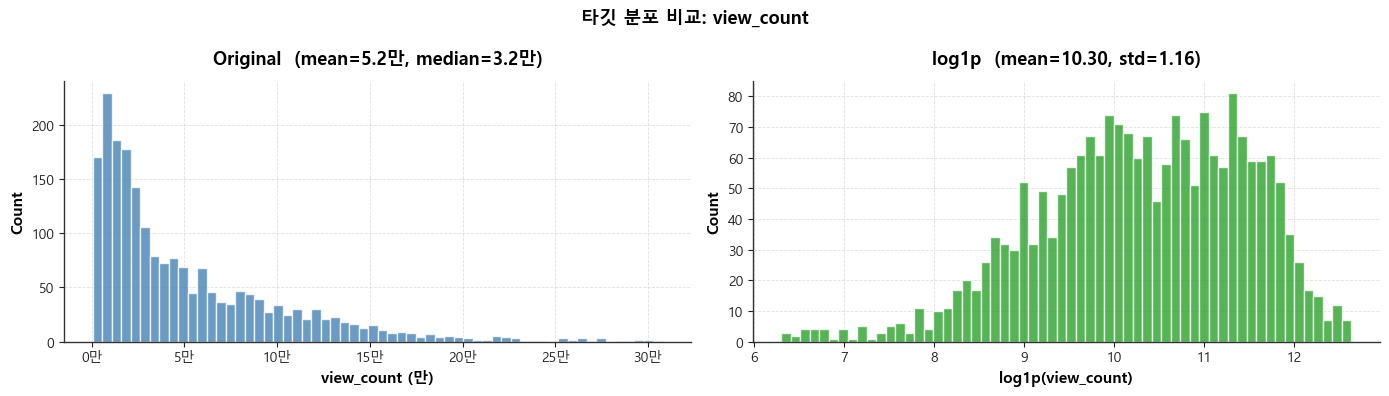

In [16]:
# view_count 분포: 원본 vs log1p
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 원본
axes[0].hist(train['view_count'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].xaxis.set_major_formatter(fmt_man)
axes[0].set_xlabel('view_count (만)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Original  (mean={train["view_count"].mean()/10000:.1f}만, '
                  f'median={train["view_count"].median()/10000:.1f}만)')

# log1p
log_vc = y_train
axes[1].hist(log_vc, bins=60, color='#2ca02c', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('log1p(view_count)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'log1p  (mean={log_vc.mean():.2f}, std={log_vc.std():.2f})')

plt.suptitle('타깃 분포 비교: view_count', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2) 수치형 피처 분포

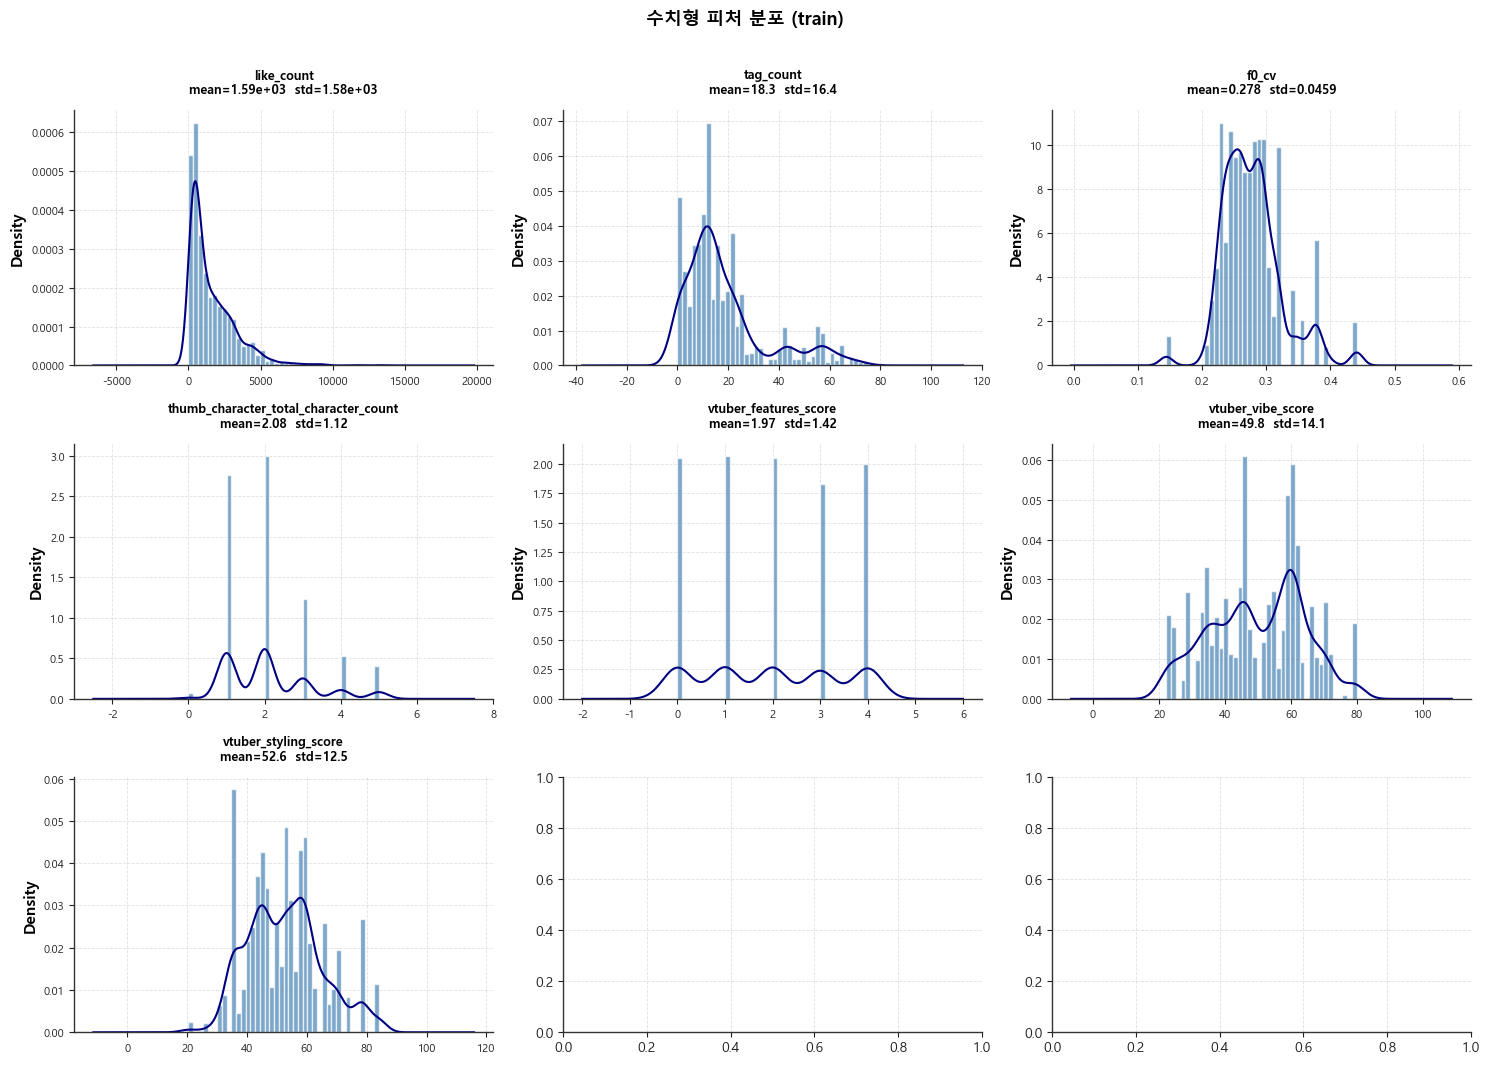

In [17]:
# 현재 활성 수치형 피처 분포 (히스토그램 + KDE)
num_cols = X_train.select_dtypes(include='number').columns.tolist()
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flat

# 피처별로 히스토그램(밀도) + KDE 곡선을 그리고, 제목에 평균·표준편차 표기
for ax, col in zip(axes, num_cols):
    data = X_train[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.7, density=True)
    data.plot.kde(ax=ax, color='navy', linewidth=1.5)
    ax.set_title(f'{col}\nmean={data.mean():.3g}  std={data.std():.3g}', fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(labelsize=8)

# 남은 subplot 숨기기
for ax in list(axes)[len(num_cols):]:
    ax.set_visible(False)

plt.suptitle('수치형 피처 분포 (train)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3) 수치형 피처 × log(view_count) 상관관계

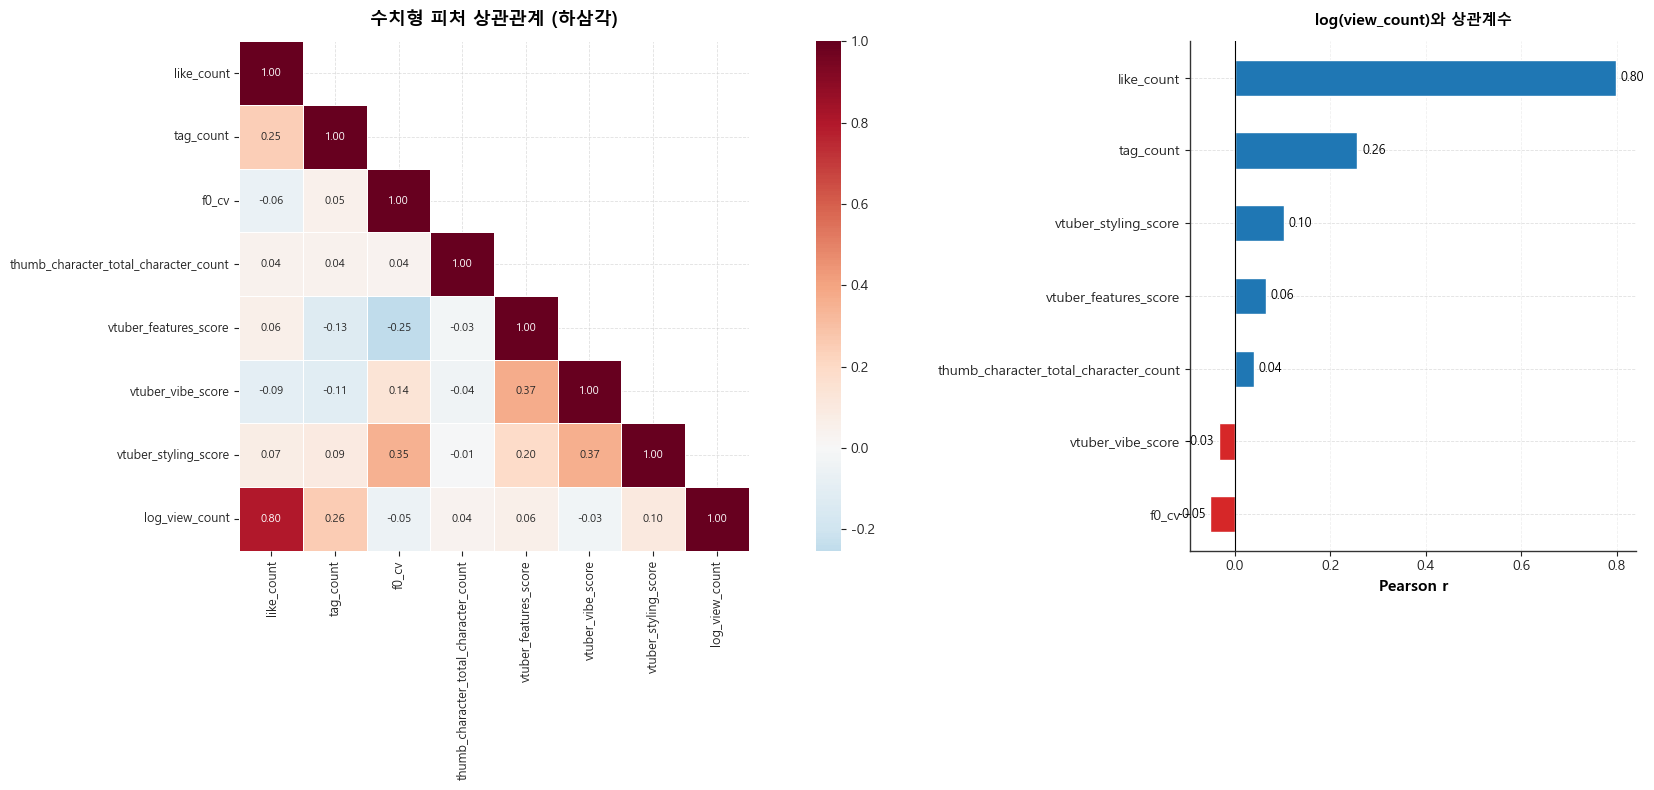

In [18]:
# 수치형 피처 + log1p(view_count) 상관관계 히트맵 & view_count 상관계수 Bar
num_cols = X_train.select_dtypes(include='number').columns.tolist()

# 수치형 피처 + 타겟(log_view_count) 을 합쳐 상관행렬 계산
corr_df = X_train[num_cols].copy()
corr_df['log_view_count'] = y_train.values
corr_mat = corr_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8),
                         gridspec_kw={'width_ratios': [3, 1]})

# (좌) 전체 히트맵
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.4, annot_kws={'size': 8},
            mask=mask, ax=axes[0])
axes[0].set_title('수치형 피처 상관관계 (하삼각)', fontsize=13, fontweight='bold')
axes[0].tick_params(labelsize=9)

# (우) view_count와의 상관계수 Bar
vc_corr = corr_mat['log_view_count'].drop('log_view_count').sort_values()
colors = ['#d62728' if v < 0 else '#1f77b4' for v in vc_corr]
vc_corr.plot.barh(ax=axes[1], color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson r')
axes[1].set_title('log(view_count)와 상관계수', fontsize=11, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# 막대 끝에 상관계수 값 라벨 표시
for i, (v, p) in enumerate(zip(vc_corr.values, vc_corr.index)):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i,
                 f'{v:.2f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

### 4) VIF 분석 (다중공선성 진단)

In [20]:
# VIF 계산 (다중공선성 진단)
# 수치형 피처만 사용 (X_train에서 직접 추출)
num_features = X_train.select_dtypes(include='number').columns.tolist()
# 식별자/타겟 제외
exclude = ['video_id', 'channel_id', 'view_count']
num_features = [c for c in num_features if c not in exclude]

X_vif = X_train[num_features].astype(float)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# VIF 값 기준 정렬
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("VIF 분석 결과 (다중공선성 진단)")
print("="*60)
print("VIF < 5    : 문제 없음")
print("VIF 5-10   : 약간 주의")
print("VIF > 10   : 심각한 다중공선성, 피처 제거 고려")
print("="*60)
print(vif_data.to_string(index=False))

# VIF > 10인 피처 하이라이트
high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\n⚠️  VIF > 10인 피처 ({len(high_vif)}개):")
    for _, row in high_vif.iterrows():
        print(f"  - {row['Feature']}: {row['VIF']:.2f}")

VIF 분석 결과 (다중공선성 진단)
VIF < 5    : 문제 없음
VIF 5-10   : 약간 주의
VIF > 10   : 심각한 다중공선성, 피처 제거 고려
                              Feature       VIF
                                f0_cv 26.081440
                 vtuber_styling_score 26.034346
                    vtuber_vibe_score 17.375422
thumb_character_total_character_count  4.241445
                vtuber_features_score  3.801212
                            tag_count  2.469453
                           like_count  2.172995

⚠️  VIF > 10인 피처 (3개):
  - f0_cv: 26.08
  - vtuber_styling_score: 26.03
  - vtuber_vibe_score: 17.38


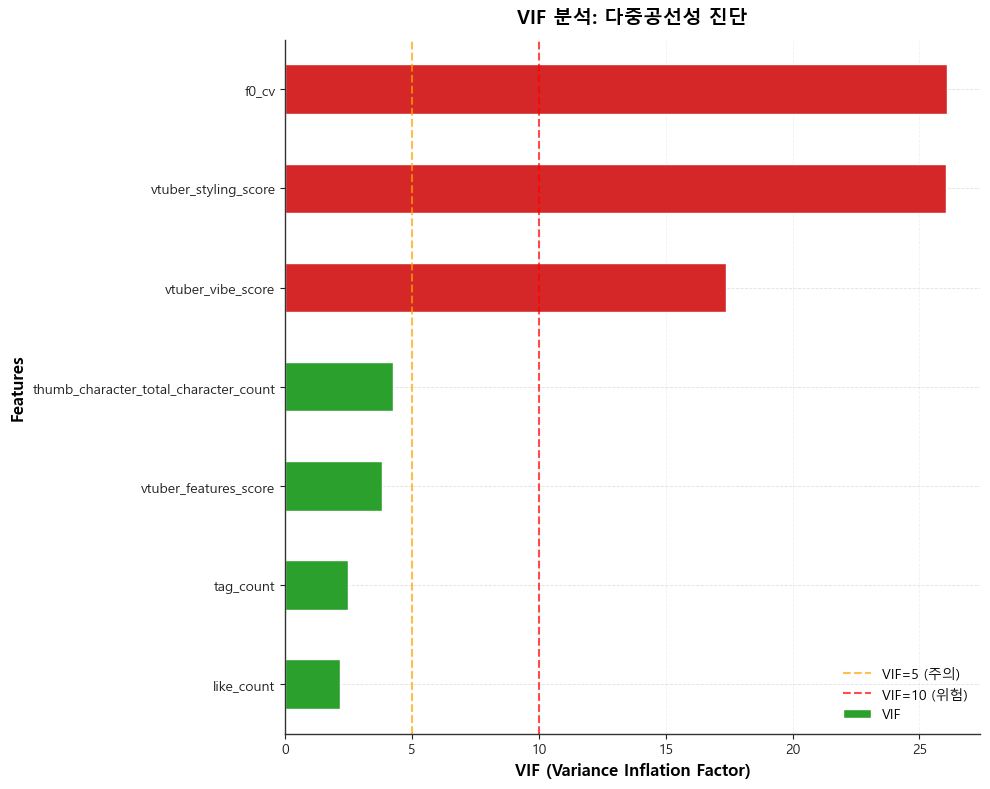

In [21]:
# VIF Bar Chart 시각화
fig, ax = plt.subplots(figsize=(10, 8))

# VIF 값 기준 정렬 (오름차순)
vif_sorted = vif_data.sort_values('VIF', ascending=True)

# Bar chart
colors = ['#d62728' if v > 10 else '#ff7f0e' if v > 5 else '#2ca02c' 
          for v in vif_sorted['VIF']]
vif_sorted.plot(x='Feature', y='VIF', kind='barh', ax=ax, color=colors, 
                edgecolor='white', legend=False)

# VIF 기준선
ax.axvline(x=5, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='VIF=5 (주의)')
ax.axvline(x=10, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='VIF=10 (위험)')

ax.set_xlabel('VIF (Variance Inflation Factor)', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('VIF 분석: 다중공선성 진단', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# VIF > 10 피처 중 상관계수 높은 짝꿍 자동 추출 & 시각화
high_vif_features = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
CORR_THRESHOLD = 0.7  # 상관계수 임계값

if len(high_vif_features) >= 2:
    corr = X_vif[high_vif_features].corr()

    # |상관계수| > 임계값인 쌍 추출
    pairs = []
    for i in range(len(corr)):
        for j in range(i+1, len(corr)):
            r = corr.iloc[i, j]
            if abs(r) > CORR_THRESHOLD:
                pairs.append((corr.index[i], corr.columns[j], r))
    pairs.sort(key=lambda x: abs(x[2]), reverse=True)

    if pairs:
        cols = min(3, len(pairs))
        rows = (len(pairs) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
        if len(pairs) == 1:
            axes = [axes]
        else:
            axes = np.array(axes).flat

        # 쌍별 산점도로 공선성을 눈으로 확인
        for ax, (f1, f2, r) in zip(axes, pairs):
            ax.scatter(X_vif[f1], X_vif[f2], alpha=0.3, s=10, color='steelblue')
            ax.set_xlabel(f1, fontsize=10)
            ax.set_ylabel(f2, fontsize=10)
            ax.set_title(f'r = {r:.2f}', fontsize=12, fontweight='bold')

        # 빈 subplot 숨기기
        for idx in range(len(pairs), rows * cols):
            list(np.array(axes).flat)[idx].set_visible(False) if rows * cols > 1 else None

        fig.suptitle(f'VIF > 10 & |상관계수| > {CORR_THRESHOLD} 인 피처 쌍',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
        print(f"\n총 {len(pairs)}개 쌍 발견 (임계값: |r| > {CORR_THRESHOLD})")
    else:
        print(f"VIF > 10인 피처 중 |상관계수| > {CORR_THRESHOLD}인 쌍이 없습니다.")
else:
    print("VIF > 10인 피처가 2개 미만입니다.")

VIF > 10인 피처 중 |상관계수| > 0.7인 쌍이 없습니다.


## 라벨 인코딩

In [23]:
# OrdinalEncoder: 범주형 컬럼 인코딩 (test 미등장 범주 → -1)
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['video_id', 'channel_id']]

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

print("인코딩 완료")
print(f"\n카테고리 매핑:")
for col, cats in zip(cat_cols, encoder.categories_):
    print(f"  {col}: {list(cats)}")

인코딩 완료

카테고리 매핑:
  worldview_type: ['SF', '기타', '동물', '신화', '없음', '판타지', '현대']
  concept_age_group_est: ['10대', '20대', '30대이상', 'unknown']
  chat_interaction_frequency: ['high', 'low', 'none', 'unknown']
  thumbnail_text_provocativeness_level: ['high', 'low', 'medium', 'none', 'unknown']
  content_category_primary_genre: ['asmr', 'challenge', 'concert_live', 'cooking', 'cover_song', 'crafts_diy', 'dance_performance', 'debate', 'drawing_art', 'education_tutorial', 'endurance_marathon', 'exercise_fitness', 'fan_art_reaction', 'gaming_fighting', 'gaming_fps', 'gaming_gacha_mobile', 'gaming_horror', 'gaming_indie', 'gaming_other', 'gaming_party', 'gaming_puzzle', 'gaming_racing', 'gaming_rhythm', 'gaming_rpg', 'gaming_simulation', 'gaming_strategy', 'gaming_survival_sandbox', 'gaming_vr', 'just_chatting', 'meme_reaction', 'mukbang', 'music_video', 'news_commentary', 'original_song', 'qna', 'review_unboxing', 'roleplay', 'short_skit', 'special_event', 'storytelling', 'video_reaction', 'vlog

In [24]:
# 데이터 형태 확인
print("X_train 식별자 드랍 전:", X_train.shape)
print("X_test 식별자 드랍 전:", X_test.shape)

# 식별자 컬럼 백업 후 드랍
test_video_ids = X_test["video_id"].values
drop_cols = ['video_id', 'channel_id']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

# 데이터 형태 확인
print("X_train 식별자 드랍 후:", X_train.shape)
print("X_test 식별자 드랍 후:", X_test.shape)

print(X_test.info())

X_train 식별자 드랍 전: (2045, 17)
X_test 식별자 드랍 전: (797, 17)
X_train 식별자 드랍 후: (2045, 15)
X_test 식별자 드랍 후: (797, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797 entries, 0 to 796
Data columns (total 15 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   like_count                              797 non-null    int64  
 1   tag_count                               797 non-null    int64  
 2   f0_cv                                   797 non-null    float64
 3   worldview_type                          797 non-null    float64
 4   concept_age_group_est                   797 non-null    float64
 5   chat_interaction_frequency              797 non-null    float64
 6   thumbnail_text_provocativeness_level    797 non-null    float64
 7   thumb_character_total_character_count   797 non-null    float64
 8   content_category_primary_genre          797 non-null    float64
 9   content_category_se

## 모델링

In [ ]:
# 모델 정의 (트리 기반만 사용)

# 모델 파라미터 (CPU)
xgb_params = {'random_state': 42}
lgbm_params = {'random_state': 42, 'verbosity': -1}
cat_params = {'random_seed': 42, 'verbose': 0}
rf_params = {'random_state': 42, 'n_jobs': -1}
et_params = {'random_state': 42, 'n_jobs': -1}

models = {
    'RandomForest': RandomForestRegressor(**rf_params),
    'XGBoost':      XGBRegressor(**xgb_params),
    'LightGBM':     LGBMRegressor(**lgbm_params),
    'CatBoost':     CatBoostRegressor(**cat_params),
}

In [26]:
# 평가 함수
def evaluate(y_true, y_pred):
    """모든 지표를 view_count 원본 스케일로 계산 (y_true/y_pred는 변환 공간 입력)."""
    view_true = tt.inverse(y_true)
    view_pred = np.clip(tt.inverse(y_pred), 0, None)
    return {
        'MSE':  mean_squared_error(view_true, view_pred),
        'RMSE': np.sqrt(mean_squared_error(view_true, view_pred)),
        'MAE':  mean_absolute_error(view_true, view_pred),
        'MAPE': mean_absolute_percentage_error(view_true, view_pred) * 100,
        'R2':   r2_score(view_true, view_pred),
    }

def run_kfold(model, X, y, n_splits=5, drop_cols=None, random_state=42):
    """KFold(shuffle=True) CV 수행. 평가는 view_count 원본 스케일 기준.
    drop_cols: 학습 전 드랍할 컬럼 리스트"""
    X_fit = X.drop(columns=drop_cols) if drop_cols else X
    y_fit = y.reset_index(drop=True)
    X_fit = X_fit.reset_index(drop=True)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_fit), 1):
        X_train, X_val = X_fit.iloc[train_idx], X_fit.iloc[val_idx]
        y_train, y_val = y_fit.iloc[train_idx], y_fit.iloc[val_idx]

        m = clone(model)
        m.fit(X_train, y_train)
        y_pred = m.predict(X_val)

        metrics = evaluate(y_val, y_pred)
        metrics['Fold'] = fold
        fold_metrics.append(metrics)

    result = pd.DataFrame(fold_metrics)[['Fold', 'MSE', 'RMSE', 'MAE', 'MAPE', 'R2']]
    mean_row = result.drop(columns='Fold').mean().to_frame().T
    mean_row.insert(0, 'Fold', 'Mean')

    return pd.concat([result, mean_row], ignore_index=True)

def run_all_models(models, X, y, n_splits=5, drop_cols=None):
    """전체 모델 CV 실행 후 결과 반환"""
    results = {}
    for name, model in models.items():
        print(f"{'='*50}\n {name}\n{'='*50}")
        result = run_kfold(model, X, y, n_splits=n_splits, drop_cols=drop_cols)
        results[name] = result
        print(result.to_string(index=False), '\n')

    summary = pd.DataFrame({
        name: df[df['Fold'] == 'Mean'].drop(columns='Fold').iloc[0]
        for name, df in results.items()
    }).T
    summary.index.name = 'Model'
    return results, summary


In [ ]:
# 시각화 / 지표 DataFrame 헬퍼 (아래 셀들에서 반복 사용)
#   - build_comparison_df : y_true vs 모델별 예측 (view_count 원 스케일)
#   - build_metrics_table : Train/Test MSE/RMSE/R²/MAPE/MAE MultiIndex DF
#   - plot_real_vs_pred_scatter : 실제 vs 예측 scatter (y=x 보조선)
#   - plot_fi_bar   : 전체 Feature Importance 가로 막대
#   - plot_fi_groups: 버츄얼/썸네일/Gemini 그룹별 FI


def build_comparison_df(models_dict, X, y_log_true, head=None):
    """y_true + 모델별 예측을 view_count 원본 스케일 DF 로 반환."""
    predictions = {"y_true": tt.inverse(y_log_true).values}
    for name, m in models_dict.items():
        predictions[name] = tt.inverse(m.predict(X))
    df = pd.DataFrame(predictions).round(0).astype(int)
    df = df.sort_values("y_true", ascending=False).reset_index(drop=True)
    return df.head(head) if head else df


def build_metrics_table(models_dict, X_tr, y_tr, X_te, y_te):
    """Train/Test 지표 MultiIndex DataFrame (MAE만 원본 스케일)."""
    rows = []
    for name, m in models_dict.items():
        train_pred = m.predict(X_tr)
        test_pred  = m.predict(X_te)
        train_met = evaluate(y_tr, train_pred)
        test_met  = evaluate(y_te,  test_pred)
        train_mae = mean_absolute_error(tt.inverse(y_tr), tt.inverse(train_pred))
        test_mae  = mean_absolute_error(tt.inverse(y_te),  tt.inverse(test_pred))
        rows.append({
            ('MSE',  'Train'): f"{train_met['MSE']:.4f}",
            ('MSE',  'Test'):  f"{test_met['MSE']:.4f}",
            ('RMSE', 'Train'): f"{train_met['RMSE']:.4f}",
            ('RMSE', 'Test'):  f"{test_met['RMSE']:.4f}",
            ('R²',   'Train'): f"{train_met['R2']:.4f}",
            ('R²',   'Test'):  f"{test_met['R2']:.4f}",
            ('MAPE', 'Train'): f"{train_met['MAPE']:.2f}%",
            ('MAPE', 'Test'):  f"{test_met['MAPE']:.2f}%",
            ('MAE',  'Train'): f"{train_mae:,.0f}",
            ('MAE',  'Test'):  f"{test_mae:,.0f}",
            '_name': name,
        })
    cols = pd.MultiIndex.from_tuples([
        ('MSE',  'Train'), ('MSE',  'Test'),
        ('RMSE', 'Train'), ('RMSE', 'Test'),
        ('R²',   'Train'), ('R²',   'Test'),
        ('MAPE', 'Train'), ('MAPE', 'Test'),
        ('MAE',  'Train'), ('MAE',  'Test'),
    ])
    out = pd.DataFrame(rows).set_index('_name')[cols]
    out.index.name = 'Model'
    return out


def plot_real_vs_pred_scatter(pairs, suptitle):
    """실제 vs 예측 산점도 (panel 여러 개). pairs: [(real, pred, title), ...]."""
    n = len(pairs)
    fig, axes = plt.subplots(1, n, figsize=(8 * n, 7))
    if n == 1:
        axes = [axes]
    for ax, (real, pred, title) in zip(axes, pairs):
        ax.scatter(real, pred, alpha=0.15, s=5, color='steelblue')
        lim = max(real.max(), pred.max())
        ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='완벽한 예측 (y=x)')
        ax.set_xlabel("실제 조회수")
        ax.set_ylabel("예측 조회수")
        ax.set_title(title)
        ax.xaxis.set_major_formatter(fmt_man)
        ax.yaxis.set_major_formatter(fmt_man)
        ax.legend()
        ax.set_aspect('equal')
        ax.set_xlim(0, lim * 1.05)
        ax.set_ylim(0, lim * 1.05)
    plt.suptitle(suptitle, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_fi_bar(fi_series, title):
    """전체 Feature Importance 가로 막대 (그라데이션)."""
    fi_sorted = fi_series.sort_values(ascending=True)
    colors_all = plot_style.gradient_colors(len(fi_sorted), "Blues")
    fig, ax = plt.subplots(figsize=(9, max(4, 0.3 * len(fi_sorted))))
    ax.barh(fi_sorted.index, fi_sorted.values,
            color=colors_all, edgecolor="white", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Feature Importance")
    ax.grid(True, axis="x")
    ax.grid(False, axis="y")
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)
    plt.tight_layout()
    plt.show()


FI_GROUPS = {
    "버츄얼 캐릭터": [
        "f0_cv",
        "worldview_type", "concept_age_group_est",
        "vtuber_features_score", "vtuber_vibe_score", "vtuber_styling_score",
    ],
    "썸네일": [
        "text_area_ratio",
        "saturation_ch_std", "contrast_ch_mean", "brightness_ch_mean",
        "thumbnail_text_provocativeness_level",
        "thumb_character_total_character_count",
    ],
    "Gemini 영상 분석": [
        "chat_interaction_frequency",
        "color_vibrancy_color_diversity_level",
        "content_category_primary_genre", "content_category_secondary_genre",
        "collaboration_collaboration_format",
        "animation_fantasy_has_fantastical_elements",
        "surprise_factor_content_surprise_level",
    ],
}


def plot_fi_groups(fi_series, title_suffix, groups=None, float_fmt="{:.4f}"):
    """버츄얼/썸네일/Gemini 그룹별 FI 가로 막대."""
    groups = groups if groups is not None else FI_GROUPS
    active = {g: [c for c in cols if c in fi_series.index]
              for g, cols in groups.items()}
    active = {g: cols for g, cols in active.items() if cols}
    if not active:
        print("[info] 시각화할 피처가 존재하지 않습니다.")
        return

    n = len(active)
    heights = [max(2.8, len(cols) * 0.5) for cols in active.values()]
    fig, axes = plt.subplots(n, 1, figsize=(10, sum(heights)),
                             gridspec_kw={"height_ratios": heights})
    if n == 1:
        axes = [axes]

    for ax, (gname, cols) in zip(axes, active.items()):
        imp = fi_series.loc[cols].sort_values(ascending=True)
        cmap_name = plot_style.GROUP_CMAPS.get(gname, "Greys")
        colors = plot_style.gradient_colors(len(imp), cmap_name)

        imp.plot.barh(ax=ax, color=colors, edgecolor='white', linewidth=0.8)
        ax.set_xlabel('Feature Importance')
        if title_suffix:
            ax.set_title(f'{gname} ({title_suffix})')

        is_int = np.allclose(imp.values, imp.values.astype(int))
        fmt = '{:,.0f}' if is_int else float_fmt

        xmax = float(imp.values.max()) if len(imp) else 1.0
        offset = xmax * 0.012
        for i, v in enumerate(imp.values):
            ax.text(v + offset, i, fmt.format(v),
                    va='center', fontsize=10, fontweight='bold', color='#222')

        ax.grid(True, axis='x')
        ax.grid(False, axis='y')
        ax.set_axisbelow(True)
        ax.margins(x=0.14)
        ax.tick_params(axis='y', length=0)

    plt.tight_layout()
    plt.show()

In [28]:
# [CONFIG] 학습 전 드랍할 컬럼 설정
# days_since_published를 피처에서 제외하려면 리스트에 포함, 포함하려면 None
# DROP_COLS = ['days_since_published']   # 제외하고 돌리기
DROP_COLS = None                         # 포함하고 돌리기

# K-Fold CV 실행
results, summary = run_all_models(models, X_train, y_train, n_splits=N_SPLITS,
                                  drop_cols=DROP_COLS)


 RandomForest
Fold          MSE         RMSE         MAE      MAPE       R2
   1 2.245754e+08 14985.839058 8496.864979 18.306740 0.922052
   2 1.952304e+08 13972.487551 7701.382868 18.361662 0.927917
   3 1.607516e+08 12678.786555 7586.846945 17.810210 0.936867
   4 1.542790e+08 12420.909792 7738.720816 17.276421 0.939682
   5 2.492988e+08 15789.198849 8115.600260 17.614399 0.909391
Mean 1.968270e+08 13969.444361 7927.883174 17.873886 0.927182 

 XGBoost
Fold          MSE         RMSE         MAE      MAPE       R2
   1 2.185140e+08 14782.219846 8428.037636 17.299453 0.924156
   2 1.793540e+08 13392.311042 7362.897339 21.183633 0.933779
   3 1.645806e+08 12828.897061 7495.508332 17.416874 0.935363
   4 2.213802e+08 14878.850000 8332.004538 16.736539 0.913448
   5 2.821777e+08 16798.146568 8555.493058 17.544533 0.897441
Mean 2.132013e+08 14536.084904 8034.788180 18.036206 0.920837 

 LightGBM
Fold          MSE         RMSE         MAE      MAPE       R2
   1 2.291573e+08 15137.942958 82

In [29]:
# 모델별 평균 성능 비교 (RMSE 순)
summary.sort_values("MAPE")

# 전체 모델 Train 전체로 학습 (이후 셀에서 재사용)
X_train_fit = X_train.drop(columns=DROP_COLS) if DROP_COLS else X_train
X_test_fit  = X_test.drop(columns=DROP_COLS)  if DROP_COLS else X_test

fitted_models = {}
for name, model in models.items():
    m = clone(model)
    m.fit(X_train_fit, y_train)
    fitted_models[name] = m
print(f"학습 완료: {list(fitted_models.keys())}")

학습 완료: ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']


In [30]:
# 전체 모델 예측값 비교 (fitted_models 재사용)
comparison = build_comparison_df(fitted_models, X_test_fit, y_test)

print(f"\n테스트 샘플 수: {len(comparison)}")
print(f"\n{'='*70}")
print("실제값(y_true) vs 모델별 예측값 비교")
comparison.head()


테스트 샘플 수: 797

실제값(y_true) vs 모델별 예측값 비교


,y_true,RandomForest,XGBoost,LightGBM,CatBoost
0,279184,207042,226609,211986,216539
1,233241,227988,224225,223168,226558
2,217710,188074,178376,180673,180004
3,216057,217265,238859,213877,239796
4,211181,189275,221684,192539,197351


## Train, Test 평가결과

In [31]:
# 전체 모델 Train/Test 평가 (fitted_models 재사용, 변환 공간)
# MAE만 원본 스케일(tt.inverse)로 표시
result_df = build_metrics_table(fitted_models, X_train_fit, y_train, X_test_fit, y_test)
result_df

,"(MSE, Train)","(MSE, Test)","(RMSE, Train)","(RMSE, Test)","(R², Train)","(R², Test)","(MAPE, Train)","(MAPE, Test)","(MAE, Train)","(MAE, Test)"
Model,,,,,,,,,,
RandomForest,36554753.4955,195808565.4450,6046.0527,13993.1614,0.9864,0.8871,6.47%,22.37%,"3,034","7,845"
XGBoost,11054198.6415,202749121.5785,3324.7855,14239.0000,0.9959,0.8831,3.84%,21.72%,"1,807","8,022"
LightGBM,89350664.1285,167302455.0486,9452.5480,12934.5450,0.9668,0.9035,10.05%,20.74%,"4,917","7,446"
CatBoost,48330995.1041,151811008.2414,6952.0497,12321.1610,0.9820,0.9124,8.57%,19.79%,"3,998","7,095"


## 모델 결과 시각화

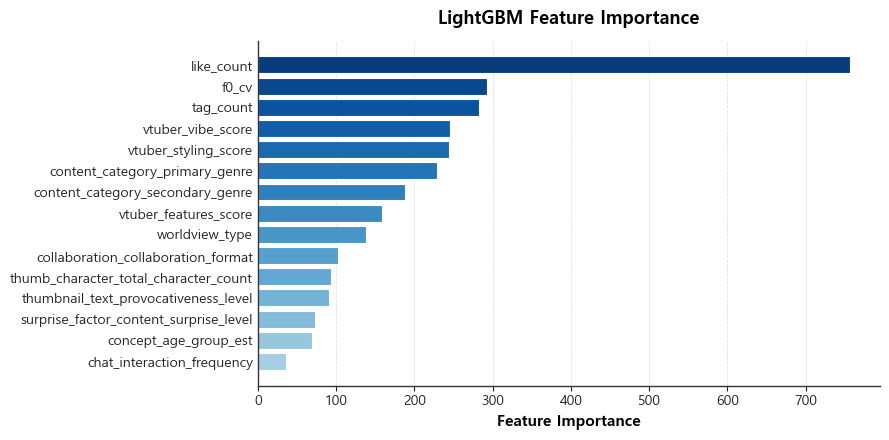

In [32]:
# Best 모델 피처 중요도 시각화 (베이스라인 LightGBM)
best_name = "LightGBM"
best_model = fitted_models[best_name]

importances = pd.Series(best_model.feature_importances_, index=X_train_fit.columns)
plot_fi_bar(importances, f"{best_name} Feature Importance")

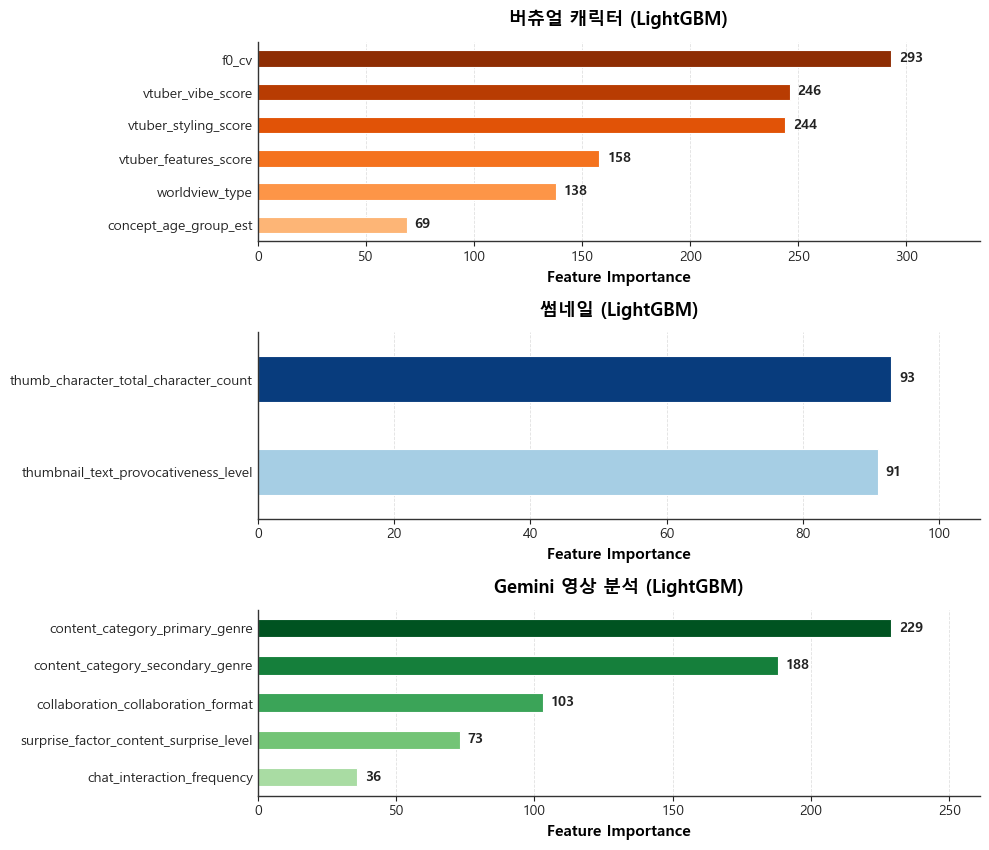

In [33]:
# 버츄얼 캐릭터 / 썸네일 / Gemini 피처 그룹별 중요도 (베이스라인 LightGBM)
plot_fi_groups(importances, title_suffix=best_name, float_fmt="{:.3f}")

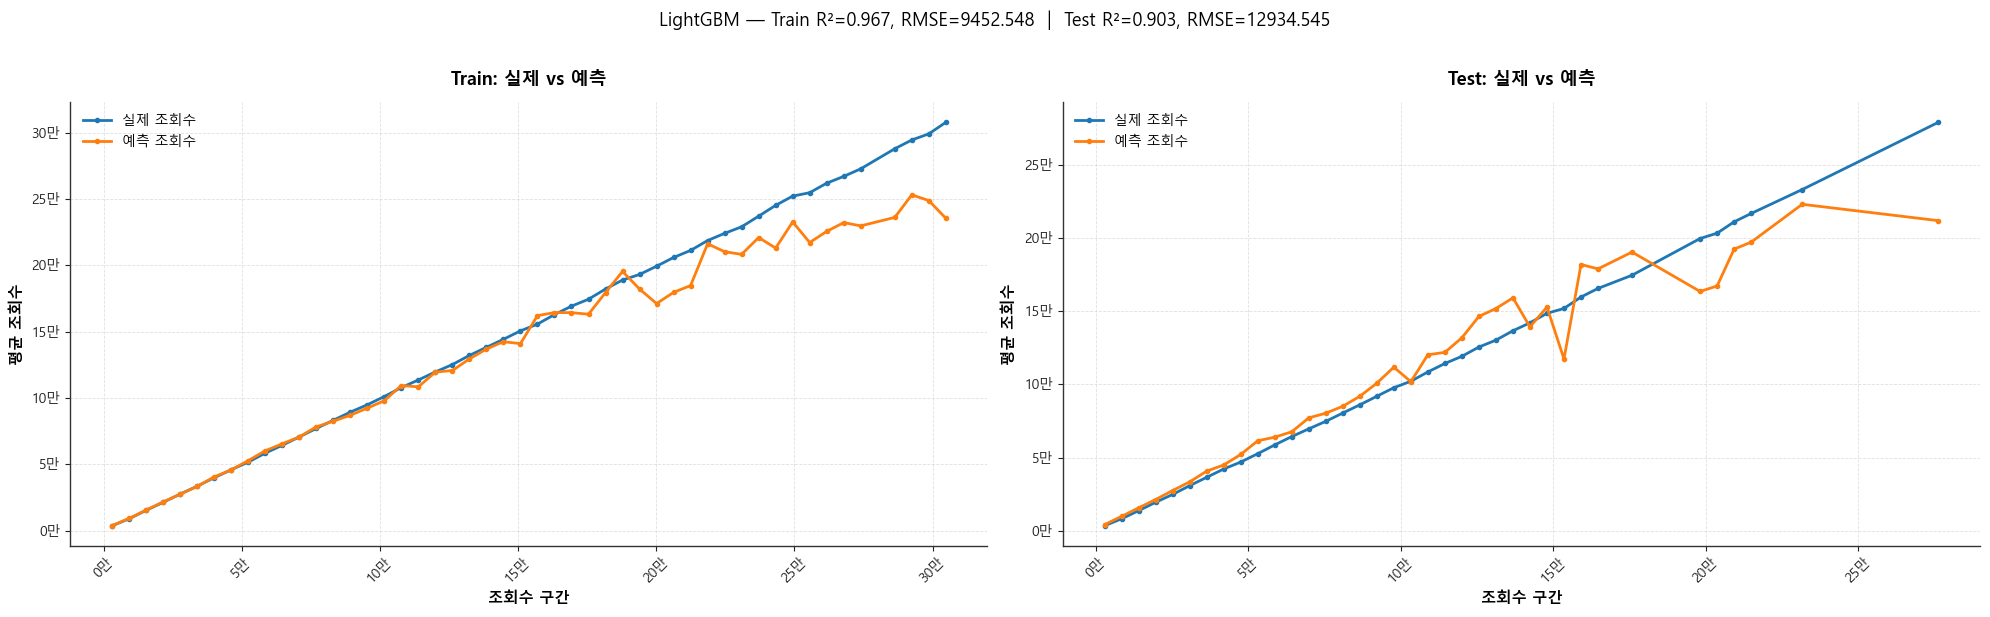

In [34]:
# Train 실제 vs 예측 | Test 실제 vs 예측  (과적합 진단)
# 시각화용 (원본 스케일)
y_train_pred = tt.inverse(best_model.predict(X_train_fit))
y_train_real = tt.inverse(y_train)
y_test_pred  = tt.inverse(best_model.predict(X_test_fit))
y_test_real  = tt.inverse(y_test)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, real, pred, title in [
    (axes[0], y_train_real, y_train_pred, "Train: 실제 vs 예측"),
    (axes[1], y_test_real,  y_test_pred,  "Test: 실제 vs 예측"),
]:
    bins = np.linspace(0, real.max(), 51)
    labels = (bins[:-1] + bins[1:]) / 2
    bin_idx = pd.cut(real, bins=bins, labels=labels)

    real_mean = real.groupby(bin_idx, observed=True).mean()
    pred_mean = pd.Series(pred, index=real.index).groupby(bin_idx, observed=True).mean()

    ax.plot(real_mean.index.astype(float), real_mean.values,
            label='실제 조회수', linewidth=2, marker='o', markersize=3)
    ax.plot(pred_mean.index.astype(float), pred_mean.values,
            label='예측 조회수', linewidth=2, marker='o', markersize=3)
    ax.xaxis.set_major_formatter(fmt_man)
    ax.yaxis.set_major_formatter(fmt_man)
    ax.set_xlabel("조회수 구간")
    ax.set_ylabel("평균 조회수")
    ax.set_title(title)
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

# 평가는 변환 공간
train_metrics = evaluate(y_train, best_model.predict(X_train_fit))
test_metrics  = evaluate(y_test, best_model.predict(X_test_fit))
fig.suptitle(
    f"{best_name} — Train R²={train_metrics['R2']:.3f}, RMSE={train_metrics['RMSE']:.3f}  |  "
    f"Test R²={test_metrics['R2']:.3f}, RMSE={test_metrics['RMSE']:.3f}",
    fontsize=13, y=1.02
)

plt.tight_layout()
plt.show()

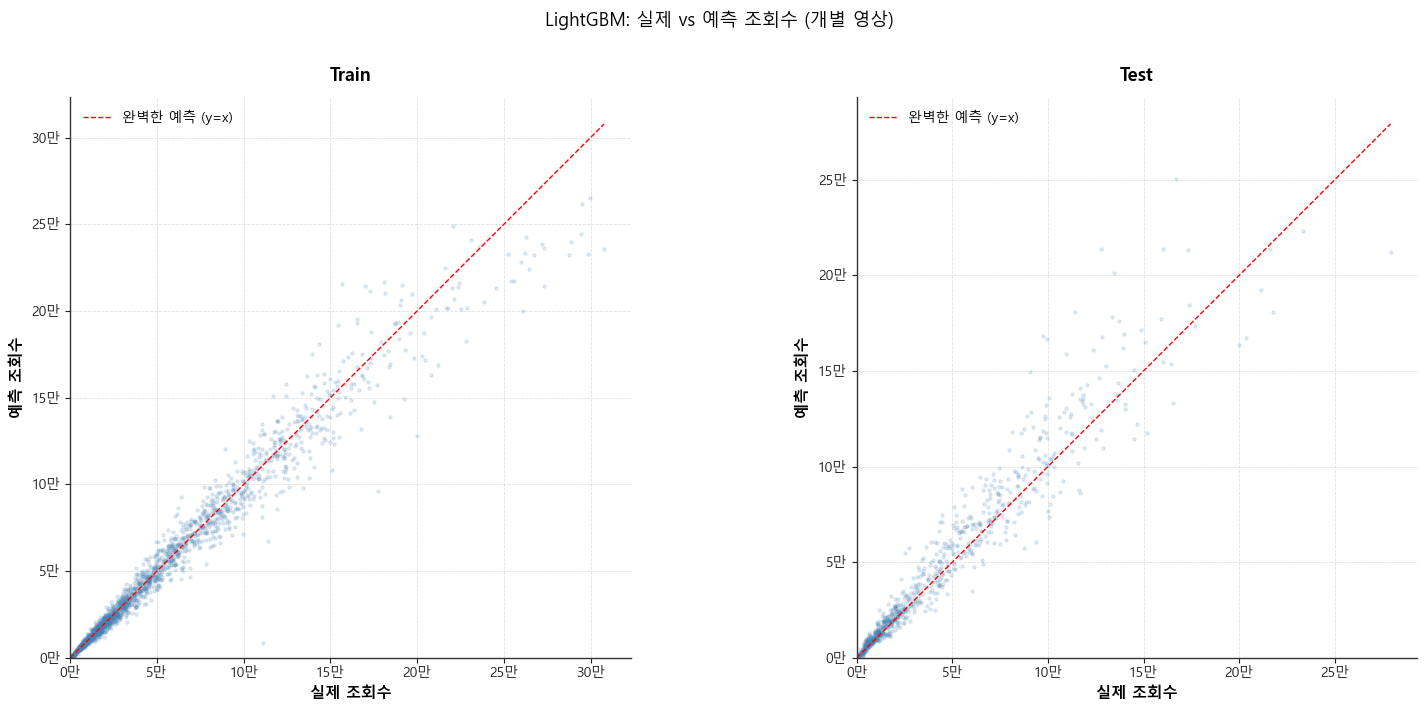

In [ ]:
# Scatter Plot: 실제 vs 예측 (개별 영상 단위) — 베이스라인 LightGBM
y_train_pred = tt.inverse(best_model.predict(X_train_fit))
y_train_real = tt.inverse(y_train)
y_test_pred  = tt.inverse(best_model.predict(X_test_fit))
y_test_real  = tt.inverse(y_test)

plot_real_vs_pred_scatter(
    [
        (y_train_real, y_train_pred, "Train"),
        (y_test_real,  y_test_pred,  "Test"),
    ],
    suptitle=f"{best_name}: 실제 vs 예측 조회수 (개별 영상)",
)

## 하이퍼 파라미터 튜닝

In [ ]:
# Baseline vs Optuna 튜닝 비교 (KFold shuffle CV)
#  - CV로 파라미터 선택
#  - CV에서 얻은 best_iter(median)로 최종 n_estimators 고정
#  - Test는 끝까지 안 건드림(누수 X)
#  - Train/Val/Test 지표 깔끔하게 출력
import optuna
import lightgbm as lgb


# 1) Metrics (입력은 변환 공간, 출력 지표는 모두 view_count 원본 스케일)
def eval_view_metrics(y_log_true, y_log_pred):
    y_true = tt.inverse(y_log_true)
    y_pred = np.clip(tt.inverse(y_log_pred), 0, None)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mae  = mean_absolute_error(y_true, y_pred)

    return {"RMSE": rmse, "R2": r2, "MAPE": mape, "MAE": mae}

# LightGBM custom eval_metric: 원본 스케일 MAPE(%) — early stopping 기준
def lgb_mape_orig(y_true, y_pred):
    yt = tt.inverse(y_true)
    yp = np.clip(tt.inverse(y_pred), 0, None)
    return "mape_orig", mean_absolute_percentage_error(yt, yp) * 100, False

# 2) KFold CV (shuffle)
def run_kfold_cv(params, X, y, n_splits=5, drop_cols=None, random_state=42):
    Xs = X.drop(columns=drop_cols) if drop_cols else X.copy()
    Xs = Xs.reset_index(drop=True)
    ys = y.reset_index(drop=True)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    rows, best_iters = [], []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(Xs), start=1):
        X_tr, X_va = Xs.iloc[tr_idx], Xs.iloc[va_idx]
        y_tr, y_va = ys.iloc[tr_idx], ys.iloc[va_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric=lgb_mape_orig,
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=0),
            ],
        )

        pred = model.predict(X_va, num_iteration=model.best_iteration_)
        met = eval_view_metrics(y_va, pred)
        rows.append({"Fold": fold, **met, "best_iter": int(model.best_iteration_)})
        best_iters.append(int(model.best_iteration_))

    df = pd.DataFrame(rows)
    mean_row = {
        "Fold": "Mean",
        "RMSE": df["RMSE"].mean(),
        "R2": df["R2"].mean(),
        "MAPE": df["MAPE"].mean(),
        "MAE": df["MAE"].mean(),
        "best_iter": int(np.median(best_iters)),
    }
    df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)
    return df


# 3) Optuna Objective (KFold shuffle)
def make_objective_kfold(X, y, n_splits=5, drop_cols=None, random_state=42):
    Xs = X.drop(columns=drop_cols) if drop_cols else X.copy()
    Xs = Xs.reset_index(drop=True)
    ys = y.reset_index(drop=True)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    def objective(trial):
        # 탐색 공간: baseline 주변으로 좁게 잡아 결과가 경계값에 붙는 걸 방지.
        # baseline 기본값을 그대로 재현할 수 있도록 상·하한을 양옆으로 여유 있게 둠.
        max_depth = trial.suggest_categorical("max_depth", [4, 5, 6])
        num_leaves = trial.suggest_int("num_leaves", 12, 31, log=True)

        params = {
            "objective": "regression",
            "verbosity": -1,
            "boosting_type": "gbdt",

            "learning_rate": trial.suggest_float("learning_rate", 0.015, 0.05, log=True),
            "num_leaves": num_leaves,
            "max_depth": max_depth,
            "min_child_samples": trial.suggest_int("min_child_samples", 80, 300, log=True),

            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 0.9),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 0.9),
            "bagging_freq": trial.suggest_categorical("bagging_freq", [1, 2, 3]),

            "lambda_l1": trial.suggest_float("lambda_l1", 0.3, 5.0, log=True),
            "lambda_l2": trial.suggest_float("lambda_l2", 0.5, 10.0, log=True),

            "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 0.1),

            # 상한(early stopping으로 best_iter 결정)
            "n_estimators": 6000,
        }

        mapes, best_iters = [], []

        for tr_idx, va_idx in kf.split(Xs):
            X_tr, X_va = Xs.iloc[tr_idx], Xs.iloc[va_idx]
            y_tr, y_va = ys.iloc[tr_idx], ys.iloc[va_idx]

            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                eval_metric=lgb_mape_orig,
                callbacks=[
                    lgb.early_stopping(stopping_rounds=50, verbose=False),
                    lgb.log_evaluation(period=0),
                ],
            )

            pred = model.predict(X_va, num_iteration=model.best_iteration_)
            met = eval_view_metrics(y_va, pred)
            mapes.append(met["MAPE"])
            best_iters.append(int(model.best_iteration_))

        trial.set_user_attr("best_iteration", int(np.median(best_iters)))
        return float(np.mean(mapes))

    return objective


# 4) 실행부
# 이전 셀에서 정의된 DROP_COLS 사용

# A) 베이스라인 파라미터
# Train/Test gap 을 줄이려고 baseline 자체를 보수적으로 고정:
# 얕은 트리(max_depth 5) + 강한 L1/L2 + 작은 learning_rate.
try:
    base_params  # 앞 셀에서 이미 정의했으면 그대로 사용
except NameError:
    base_params = {
        "objective": "regression",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "n_estimators": 6000,
        "learning_rate": 0.03,
        "num_leaves": 20,
        "max_depth": 5,
        "min_child_samples": 100,
        "feature_fraction": 0.7,
        "bagging_fraction": 0.7,
        "bagging_freq": 1,
        "lambda_l1": 0.5,
        "lambda_l2": 1.0,
    }

# 1) 베이스라인 CV
baseline_cv = run_kfold_cv(base_params, X_train, y_train, n_splits=5, drop_cols=DROP_COLS)
baseline_mean = baseline_cv[baseline_cv["Fold"] == "Mean"].iloc[0].to_dict()
baseline_best_iter = int(baseline_mean["best_iter"])

# 2) Optuna 튜닝
# multivariate TPE 로 파라미터 간 상관까지 고려해 탐색.
# baseline 을 trial 0 으로 enqueue → 더 나은 영역을 못 찾아도 최소 baseline 성능은 보장.
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(multivariate=True, seed=42),
)
# baseline 을 trial 0 으로 정확히 재현 (min_gain_to_split 도 base_params 기본값 0.0 으로 맞춤)
study.enqueue_trial({
    "max_depth": 5,
    "num_leaves": 20,
    "learning_rate": 0.03,
    "min_child_samples": 100,
    "feature_fraction": 0.7,
    "bagging_fraction": 0.7,
    "bagging_freq": 1,
    "lambda_l1": 0.5,
    "lambda_l2": 1.0,
    "min_gain_to_split": 0.0,
})
study.optimize(
    make_objective_kfold(X_train, y_train, n_splits=5, drop_cols=DROP_COLS),
    n_trials=50
)

tuned_best_iter = int(study.best_trial.user_attrs.get("best_iteration", 1000))

tuned_params = {
    **base_params,
    **study.best_params,
    "n_estimators": 6000,  # 상한(최종은 아래에서 best_iter로 고정)
}

# 3) 튠 모델 CV
tuned_cv = run_kfold_cv(tuned_params, X_train, y_train, n_splits=5, drop_cols=DROP_COLS)
tuned_mean = tuned_cv[tuned_cv["Fold"] == "Mean"].iloc[0].to_dict()

# 4) 최종 학습: best_iter 고정 (누수 0)
def fit_final_fixed_iter(params, best_iter, X_tr, y_tr, X_te, y_te):
    p = dict(params)
    p["n_estimators"] = int(best_iter)
    p.pop("metric", None)

    model = lgb.LGBMRegressor(**p)
    model.fit(X_tr, y_tr)

    train_pred = model.predict(X_tr)
    test_pred  = model.predict(X_te)

    return eval_view_metrics(y_tr, train_pred), eval_view_metrics(y_te, test_pred), model

base_train_met, base_test_met, _ = fit_final_fixed_iter(base_params, baseline_best_iter, X_train_fit, y_train, X_test_fit, y_test)
tune_train_met, tune_test_met, final_model = fit_final_fixed_iter(tuned_params, tuned_best_iter, X_train_fit, y_train, X_test_fit, y_test)

# 5) 최종 비교표
baseline_mape = float(baseline_mean["MAPE"])
tuned_mape    = float(tuned_mean["MAPE"])
improve_pct   = (baseline_mape - tuned_mape) / baseline_mape * 100

compare = pd.DataFrame([
    {
        "Model": "Baseline",
        "CV_RMSE": baseline_mean["RMSE"],
        "CV_R2": baseline_mean["R2"],
        "CV_MAE": baseline_mean["MAE"],
        "CV_MAPE": baseline_mean["MAPE"],
        "FixedIter(n_estimators)": baseline_best_iter,
        "Train_RMSE": base_train_met["RMSE"],
        "Test_RMSE": base_test_met["RMSE"],
        "Train_R2": base_train_met["R2"],
        "Test_R2": base_test_met["R2"],
        "Train_MAE": base_train_met["MAE"],
        "Test_MAE": base_test_met["MAE"],
        "Train_MAPE": base_train_met["MAPE"],
        "Test_MAPE": base_test_met["MAPE"],
    },
    {
        "Model": "Optuna Tuned",
        "CV_RMSE": tuned_mean["RMSE"],
        "CV_R2": tuned_mean["R2"],
        "CV_MAE": tuned_mean["MAE"],
        "CV_MAPE": tuned_mean["MAPE"],
        "FixedIter(n_estimators)": tuned_best_iter,
        "Train_RMSE": tune_train_met["RMSE"],
        "Test_RMSE": tune_test_met["RMSE"],
        "Train_R2": tune_train_met["R2"],
        "Test_R2": tune_test_met["R2"],
        "Train_MAE": tune_train_met["MAE"],
        "Test_MAE": tune_test_met["MAE"],
        "Train_MAPE": tune_train_met["MAPE"],
        "Test_MAPE": tune_test_met["MAPE"],
    }
])

for c in ["CV_R2", "Train_R2", "Test_R2",
          "CV_MAPE", "Train_MAPE", "Test_MAPE"]:
    compare[c] = compare[c].astype(float).round(4)

for c in ["CV_RMSE", "Train_RMSE", "Test_RMSE",
          "CV_MAE", "Train_MAE", "Test_MAE"]:
    compare[c] = compare[c].astype(float).round(0).astype(int)

print("="*70)
print("Optuna Best params:", study.best_params)
print("Optuna best_iteration(median from CV):", tuned_best_iter)
print(f"CV MAPE 개선율: {improve_pct:.2f}%  (Baseline {baseline_mape:.2f} → Tuned {tuned_mape:.2f})")
print("="*70)

print("\n[Baseline CV folds]")
print(baseline_cv)

print("\n[Tuned CV folds]")
print(tuned_cv)

print("\n[최종 비교표]")
display(compare)

In [37]:
# Optuna 시각화 유틸 (필요 시 주석 해제)
#   - study (LGBM) / study_cb 각각 시각화 가능
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_contour,
    plot_parallel_coordinate,
)

# 예시: LightGBM study 기준 (study_cb 로 바꿔 쓰면 됨)
plot_optimization_history(study).show()
plot_param_importances(study).show()
# plot_slice(study).show()
# plot_contour(study).show()
plot_parallel_coordinate(study).show()

In [38]:
# Optuna 튜닝된 LightGBM 을 fitted_models 에 등록
fitted_models["LightGBM (Optuna)"] = final_model
print("fitted_models['LightGBM (Optuna)'] 등록 완료")

fitted_models['LightGBM (Optuna)'] 등록 완료


## 모델 & 앙상블 성능 비교

- 7모델 개별 지표 + 앙상블 subset 전수조사로 best 선정
- 이후 셀들은 `best_pred` / `best_name` / `is_ensemble` / `best_combo` 를 공통으로 사용


In [39]:
# 튜닝 후 전체 모델 통합 성능 비교 (view_count 원 스케일)
import numpy as np
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error,
)

y_true_view = tt.inverse(y_test).values

# 학습된 전체 모델을 돌며 Test 성능(MAPE/RMSE/R2/MAE) 계산
rows = []
for name, m in fitted_models.items():
    y_pred_view = np.clip(tt.inverse(m.predict(X_test_fit)), 0, None)
    rows.append({
        "Model":   name,
        "MAPE(%)": mean_absolute_percentage_error(y_true_view, y_pred_view) * 100,
        "RMSE":    np.sqrt(mean_squared_error(y_true_view, y_pred_view)),
        "R2":      r2_score(y_true_view, y_pred_view),
        "MAE":     mean_absolute_error(y_true_view, y_pred_view),
    })

metrics_df = (pd.DataFrame(rows)
                .sort_values("MAPE(%)")
                .reset_index(drop=True)
                .round(4))

print(f"테스트 샘플 수: {len(y_true_view)}")

print()
print("[실제 vs 예측 상위 10]")
display(build_comparison_df(fitted_models, X_test_fit, y_test, head=10))

print()
print("[모델별 Test 성능 — MAPE 낮은 순]")
metrics_df

테스트 샘플 수: 797

[실제 vs 예측 상위 10]


,y_true,RandomForest,XGBoost,LightGBM,CatBoost,LightGBM (Optuna)
0,279184,207042,226609,211986,216539,203234
1,233241,227988,224225,223168,226558,204640
2,217710,188074,178376,180673,180004,172779
3,216057,217265,238859,213877,239796,180897
4,211181,189275,221684,192539,197351,219921
5,203416,150800,183443,167347,184674,191773
6,199781,156578,173165,163571,162568,174674
7,176899,179851,168317,173550,188039,193243
8,173858,162522,189678,184616,182100,191369
9,173273,198665,156798,213379,186124,180282



[모델별 Test 성능 — MAPE 낮은 순]


,Model,MAPE(%),RMSE,R2,MAE
0,CatBoost,19.7872,12321.1610,0.9124,7095.4096
1,LightGBM,20.7361,12934.5450,0.9035,7446.0985
2,LightGBM (Optuna),21.1539,14326.4267,0.8816,7751.3724
3,XGBoost,21.7198,14239.0000,0.8831,8022.3267
4,RandomForest,22.3680,13993.1614,0.8871,7845.1627


In [40]:
# Best = LightGBM (Optuna) 단독 선택
#   - 하위 셀(scatter / FI / SHAP / 저장) 호환용 변수 세팅
import numpy as np

best_name  = "LightGBM (Optuna)" if "LightGBM (Optuna)" in fitted_models else "LightGBM"
best_model = fitted_models[best_name]
best_pred  = np.clip(tt.inverse(best_model.predict(X_test_fit)), 0, None)
is_ensemble = False
best_combo  = (best_name,)

print(f"[Best] {best_name}")


[Best] LightGBM (Optuna)


## Best 기준 시각화 — 실제 vs 예측


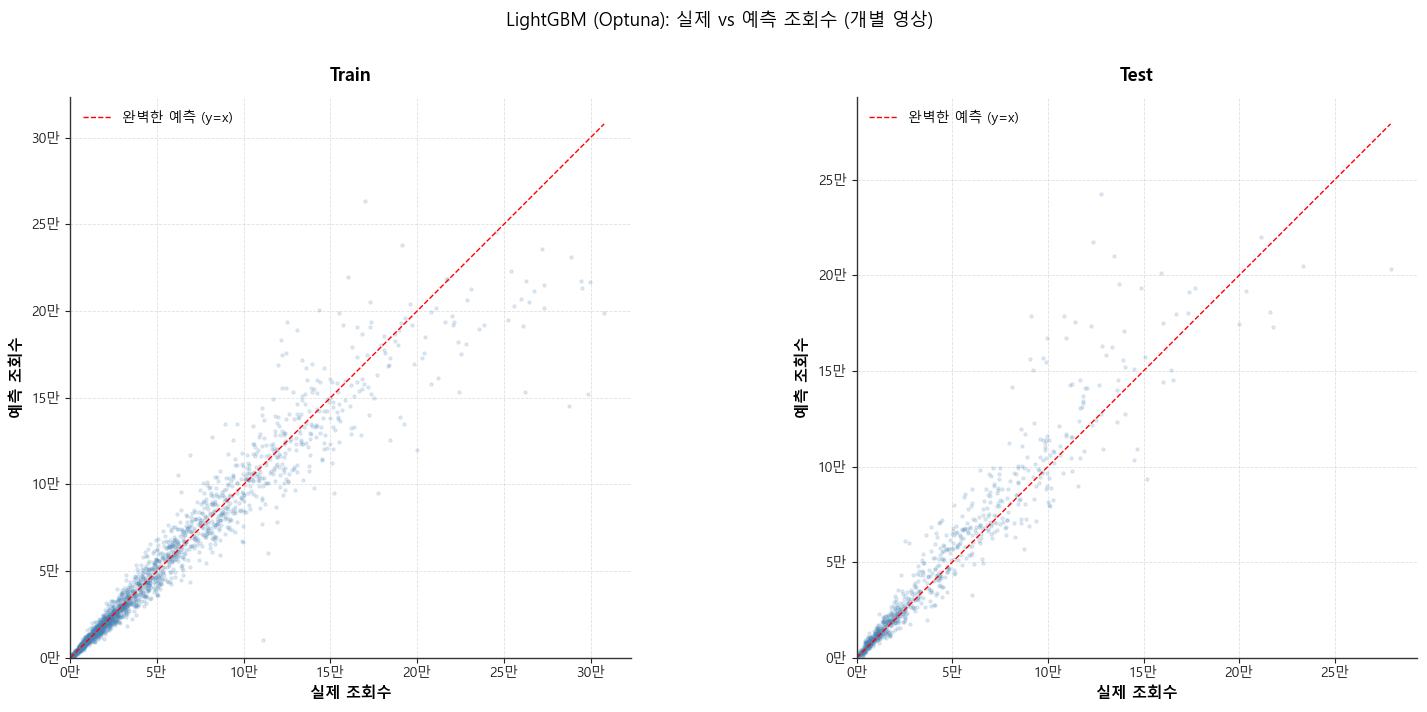

In [41]:
# Scatter Plot: 실제 vs 예측 (개별 영상 단위) — Best 기준
import numpy as np

y_train_pred = np.clip(tt.inverse(fitted_models[best_name].predict(X_train_fit)), 0, None)
y_train_real = tt.inverse(y_train)
y_test_pred  = best_pred
y_test_real  = tt.inverse(y_test)

plot_real_vs_pred_scatter(
    [
        (y_train_real, y_train_pred, "Train"),
        (y_test_real,  y_test_pred,  "Test"),
    ],
    suptitle=f"{best_name}: 실제 vs 예측 조회수 (개별 영상)",
)

## Feature Importance (Best 기준)


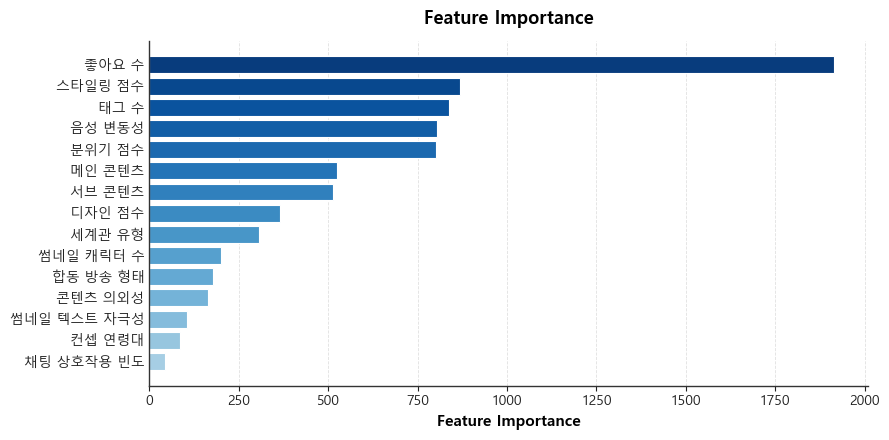

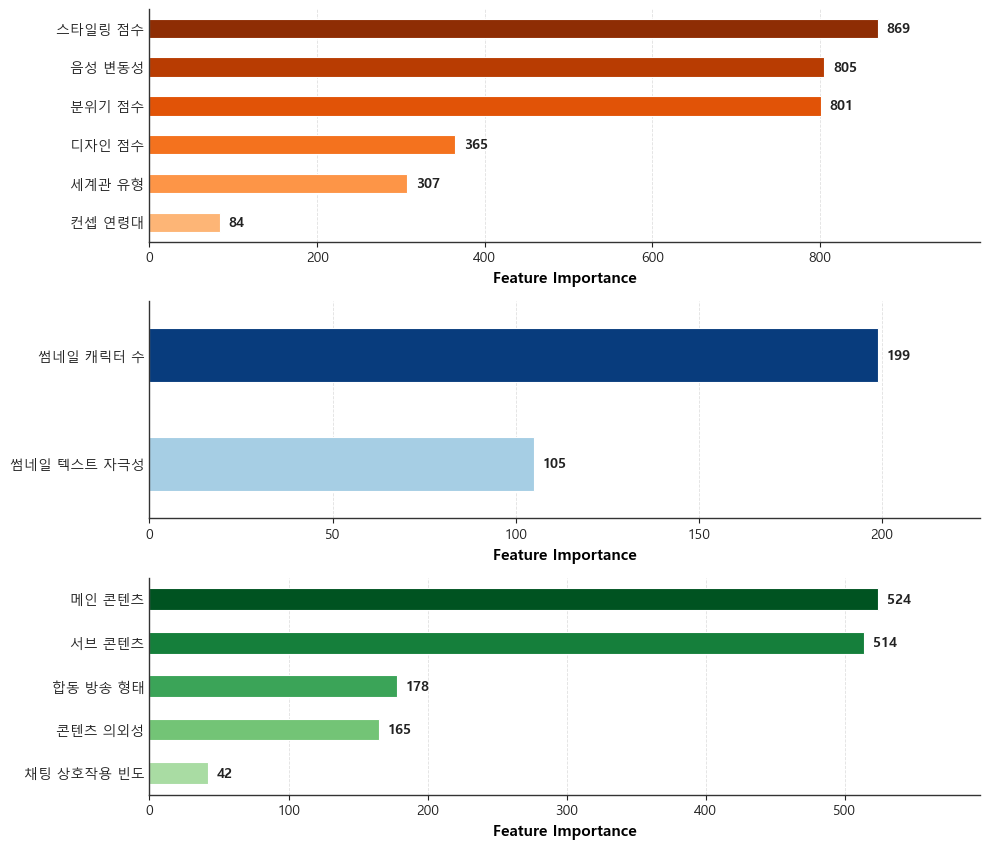

In [42]:
# Best 기준 Feature Importance
import numpy as np

# [임시] 학술지 발표/논문용 피처명 한국어 표시
#   - 이 셀에서만 적용 (fi_series/FI_GROUPS 복사본에만 rename).
#   - 원본 train/test/X_train_fit 컬럼명은 영문 그대로 유지 → 하류 코드 영향 X.
#   - 논문 작성 완료 후 RENAME_KR 블록과 *_kr 관련 코드 삭제 예정.
RENAME_KR = {
    "like_count": "좋아요 수",
    "tag_count": "태그 수",
    "f0_cv": "음성 변동성",
    "worldview_type": "세계관 유형",
    "concept_age_group_est": "컨셉 연령대",
    "chat_interaction_frequency": "채팅 상호작용 빈도",
    "thumbnail_text_provocativeness_level": "썸네일 텍스트 자극성",
    "thumb_character_total_character_count": "썸네일 캐릭터 수",
    "content_category_primary_genre": "메인 콘텐츠",
    "content_category_secondary_genre": "서브 콘텐츠",
    "collaboration_collaboration_format": "합동 방송 형태",
    "surprise_factor_content_surprise_level": "콘텐츠 의외성",
    "vtuber_features_score": "디자인 점수",
    "vtuber_vibe_score": "분위기 점수",
    "vtuber_styling_score": "스타일링 점수",
}


def _get_fi(model, n_features):
    fi = getattr(model, "feature_importances_", None)
    if fi is None or len(fi) != n_features:
        return None
    return np.asarray(fi, dtype=float)


feat_names = list(X_train_fit.columns)
model = fitted_models[best_name]
fi_raw = _get_fi(model, len(feat_names))
if fi_raw is None:
    raise ValueError(f"{best_name} 에 feature_importances_ 가 없습니다.")
fi_series = pd.Series(fi_raw, index=feat_names)

# [임시] 한국어 표시용 사본 생성 (plot_fi_groups는 FI_GROUPS로 그룹 매칭하므로 groups도 함께 rename)
fi_series_kr = fi_series.rename(index=RENAME_KR)
FI_GROUPS_KR = {g: [RENAME_KR.get(c, c) for c in cols] for g, cols in FI_GROUPS.items()}

# 1) 전체 FI (상단 타이틀만 "Feature Importance")
plot_fi_bar(fi_series_kr, "Feature Importance")

# 2) 버츄얼 / 썸네일 / Gemini 피처 그룹별 FI (subplot 제목 없음)
plot_fi_groups(fi_series_kr, title_suffix="", groups=FI_GROUPS_KR, float_fmt="{:.4f}")

## SHAP 분석 (Best 기준)


  LightGBM (Optuna)              SHAP OK  shape=(797, 15)

[단일 모델 SHAP] LightGBM (Optuna)



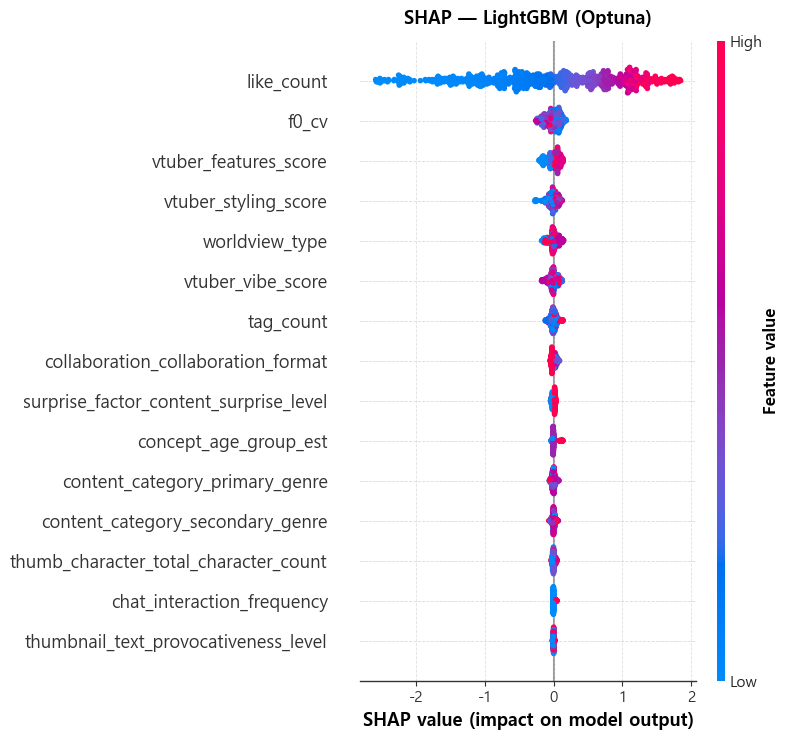

In [43]:
# Best 기준 SHAP 분석
#   - 단일: 해당 모델 SHAP
#   - 앙상블: 구성 모델별 SHAP 값을 log1p 공간에서 평균
#     (앙상블 예측이 log-space 평균이므로 SHAP 선형성으로 정당화됨)
EXCLUDE = []  # 표시 제외할 피처

import shap
import numpy as np

display_cols = [c for c in X_test_fit.columns if c not in EXCLUDE]
X_shap = X_test_fit[display_cols].copy()

shap_vals_list = []
valid_models = []
expected_values = []

for mname in best_combo:
    m = fitted_models.get(mname)
    if m is None:
        print(f"[warn] {mname} 없음, 스킵")
        continue
    try:
        explainer = shap.TreeExplainer(m)
        sv = explainer.shap_values(X_shap)
        sv = np.asarray(sv)
        shap_vals_list.append(sv)
        valid_models.append(mname)
        ev = explainer.expected_value
        if isinstance(ev, (list, np.ndarray)) and np.ndim(ev) > 0:
            ev = float(np.asarray(ev).ravel()[0])
        expected_values.append(float(ev))
        print(f"  {mname:30s} SHAP OK  shape={sv.shape}")
    except Exception as e:
        print(f"  {mname:30s} SHAP 실패: {e!r}")

if not shap_vals_list:
    raise RuntimeError("SHAP 계산 가능한 모델이 없음")

print()
if is_ensemble and len(valid_models) > 1:
    shap_values = np.mean(shap_vals_list, axis=0)
    expected_value = float(np.mean(expected_values))
    plot_title = f"SHAP (Ensemble avg of {len(valid_models)} models)"
    print(f"[앙상블 SHAP] 평균 대상: {valid_models}")
else:
    shap_values = shap_vals_list[0]
    expected_value = expected_values[0]
    plot_title = f"SHAP — {valid_models[0]}"
    print(f"[단일 모델 SHAP] {valid_models[0]}")
print()

# 요약 플롯
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X_shap, show=False)
plt.title(plot_title)
plt.tight_layout()
plt.show()

# 개별 샘플 워터폴 (필요 시 아래 주석 해제)
# idx = 723  # X_test_fit iloc 위치
# sv_one = shap.Explanation(
#     values=shap_values[idx],
#     base_values=expected_value,
#     data=X_shap.iloc[idx].values,
#     feature_names=X_shap.columns.tolist(),
# )
# shap.plots.waterfall(sv_one, max_display=20, show=True)

전체 피처  : 15
영상단위   : 15
채널단위 제외 (0): []



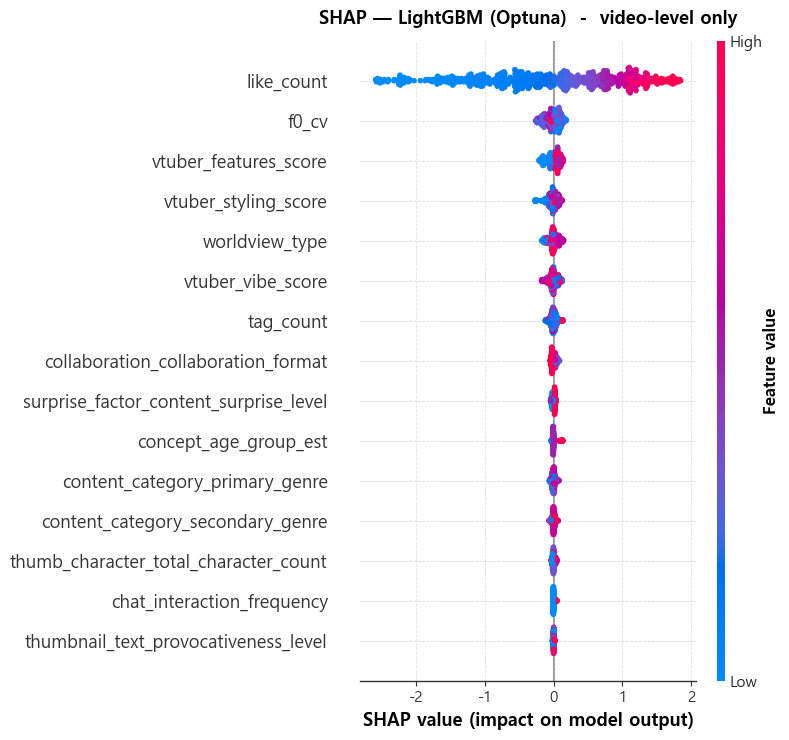

In [ ]:
# SHAP 분석 - 채널 메타데이터 제외 (영상단위 피처만)
#   - 위 셀에서 계산된 shap_values, X_shap, plot_title 재사용 (SHAP 재계산 X)
#   - 채널단위(모든 영상이 동일값)인 피처는 제외하고 영상 단위 기여도만 확인
#   - 아래 CHANNEL_META_COLS / _is_channel_meta 를 주석 해제해야 필터링됨
#     (정의 없으면 이 셀은 그냥 스킵)
import shap
import matplotlib.pyplot as plt
import numpy as np

# 명시적 채널 메타데이터 (채널단위로 값이 고정되는 피처)
CHANNEL_META_COLS = {
    "like_count"
}

def _is_channel_meta(col: str) -> bool:
    return (
        col in CHANNEL_META_COLS
        or col.startswith("jnn_")      # JNN 피처는 채널단위 집계
        or col.endswith("_ch_mean") or col.endswith("_ch_std")
        or col.endswith("_ch_min")  or col.endswith("_ch_max")
    )

if "_is_channel_meta" not in globals():
    print("[skip] _is_channel_meta 정의 없음 — 위 주석을 해제하면 실행됩니다.")
else:
    keep_mask = np.array([not _is_channel_meta(c) for c in X_shap.columns])
    keep_cols = X_shap.columns[keep_mask].tolist()
    drop_cols = X_shap.columns[~keep_mask].tolist()

    X_shap_video      = X_shap.loc[:, keep_cols]
    shap_values_video = shap_values[:, keep_mask]

    print(f"전체 피처  : {X_shap.shape[1]}")
    print(f"영상단위   : {len(keep_cols)}")
    print(f"채널단위 제외 ({len(drop_cols)}): {drop_cols}")
    print()

    shap.summary_plot(shap_values_video, X_shap_video, show=False)
    plt.title(f"{plot_title}  -  video-level only")
    plt.tight_layout()
    plt.show()

전체 피처  : 15
영상단위   : 14
채널단위 제외 (1): ['like_count']



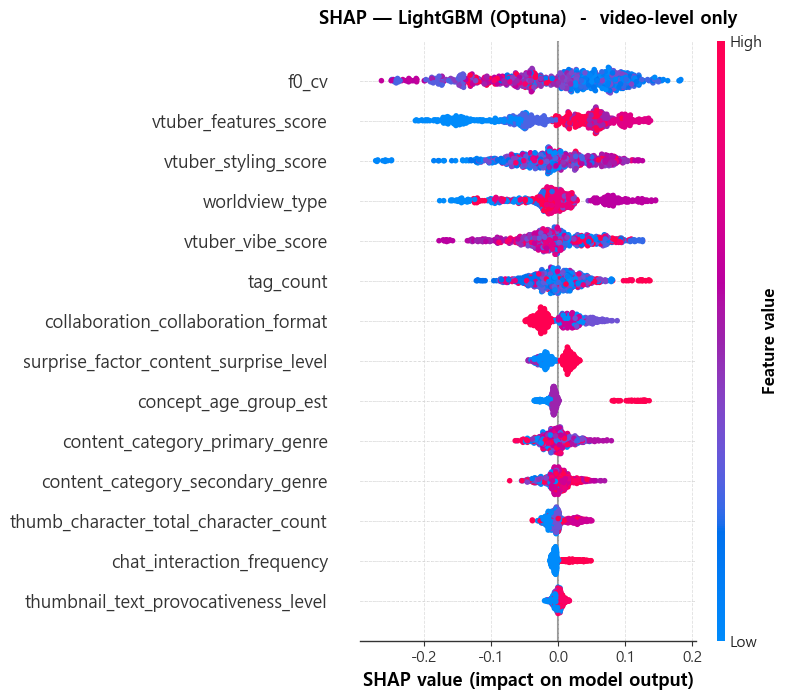

In [45]:
# SHAP 분석 - 채널 메타데이터 제외 (영상단위 피처만)
#   - 위 셀에서 계산된 shap_values, X_shap, plot_title 재사용 (SHAP 재계산 X)
#   - 채널단위(모든 영상이 동일값)인 피처는 제외하고 영상 단위 기여도만 확인
import shap
import matplotlib.pyplot as plt
import numpy as np

# 명시적 채널 메타데이터 (채널단위로 값이 고정되는 피처)
CHANNEL_META_COLS = {
    # 채널 규모/메타
    "subscriber_count", "video_count", "like_count", "comment_count", "days_since_published",
    "channel_title",
    # 채널단위 수치
    "like_ratio", "comment_ratio"
}

def _is_channel_meta(col: str) -> bool:
    return (
        col in CHANNEL_META_COLS
        or col.startswith("jnn_")      # JNN 피처는 채널단위 집계
        or col.endswith("_ch_mean") or col.endswith("_ch_std")
        or col.endswith("_ch_min")  or col.endswith("_ch_max")
    )

keep_mask = np.array([not _is_channel_meta(c) for c in X_shap.columns])
keep_cols = X_shap.columns[keep_mask].tolist()
drop_cols = X_shap.columns[~keep_mask].tolist()

X_shap_video      = X_shap.loc[:, keep_cols]
shap_values_video = shap_values[:, keep_mask]

print(f"전체 피처  : {X_shap.shape[1]}")
print(f"영상단위   : {len(keep_cols)}")
print(f"채널단위 제외 ({len(drop_cols)}): {drop_cols}")
print()

shap.summary_plot(shap_values_video, X_shap_video, show=False)
plt.title(f"{plot_title}  -  video-level only")
plt.tight_layout()
plt.show()

## 보조 분석 — 흥행 요소 도출 (학술지용)

SHAP summary가 like_count에 압살되어 분포가 안 보이는 문제를 보완하는 3가지 보조 분석:
- **(C) 흥행 그룹 vs 비흥행 그룹 박스플롯 + Mann-Whitney** — SHAP 안 쓰고 통계로 직접 검증
- **(B) PDP (Partial Dependence Plot)** — 피처값 변화에 따른 예측 곡선
- **(A) SHAP Dependence Plot** — 피처별 개별 (summary 짜부와 별개로 잘 보임)

상위 20% 컷: 74,320회 (n=160)
하위 20% 컷: 9,080회 (n=160)

=== Mann-Whitney U (흥행 vs 비흥행) — p값 오름차순 ===
 feature_kr  high_median  low_median direction      p_value
       태그 수    20.000000   12.000000         + 5.535502e-12
     세계관 유형     5.000000    4.000000         + 9.439228e-08
    스타일링 점수    57.626529   48.082266         + 5.317552e-04
   합동 방송 형태     2.000000    3.000000         - 1.114481e-03
  썸네일 캐릭터 수     2.000000    2.000000         - 4.278709e-03
     컨셉 연령대     1.000000    1.000000         - 7.879224e-03
     메인 콘텐츠    28.000000   26.000000         + 1.812946e-02
     음성 변동성     0.257997    0.267355         - 4.706775e-02
    콘텐츠 의외성     3.000000    3.000000         - 5.564049e-02
     디자인 점수     2.000000    2.000000         - 1.945542e-01
썸네일 텍스트 자극성     3.000000    3.000000         - 3.546645e-01
     서브 콘텐츠    28.000000   28.000000         - 4.263261e-01
 채팅 상호작용 빈도     0.000000    0.000000         - 6.709944e-01
     분위기 점수    46.669170   45.396027         + 7.601694e-01


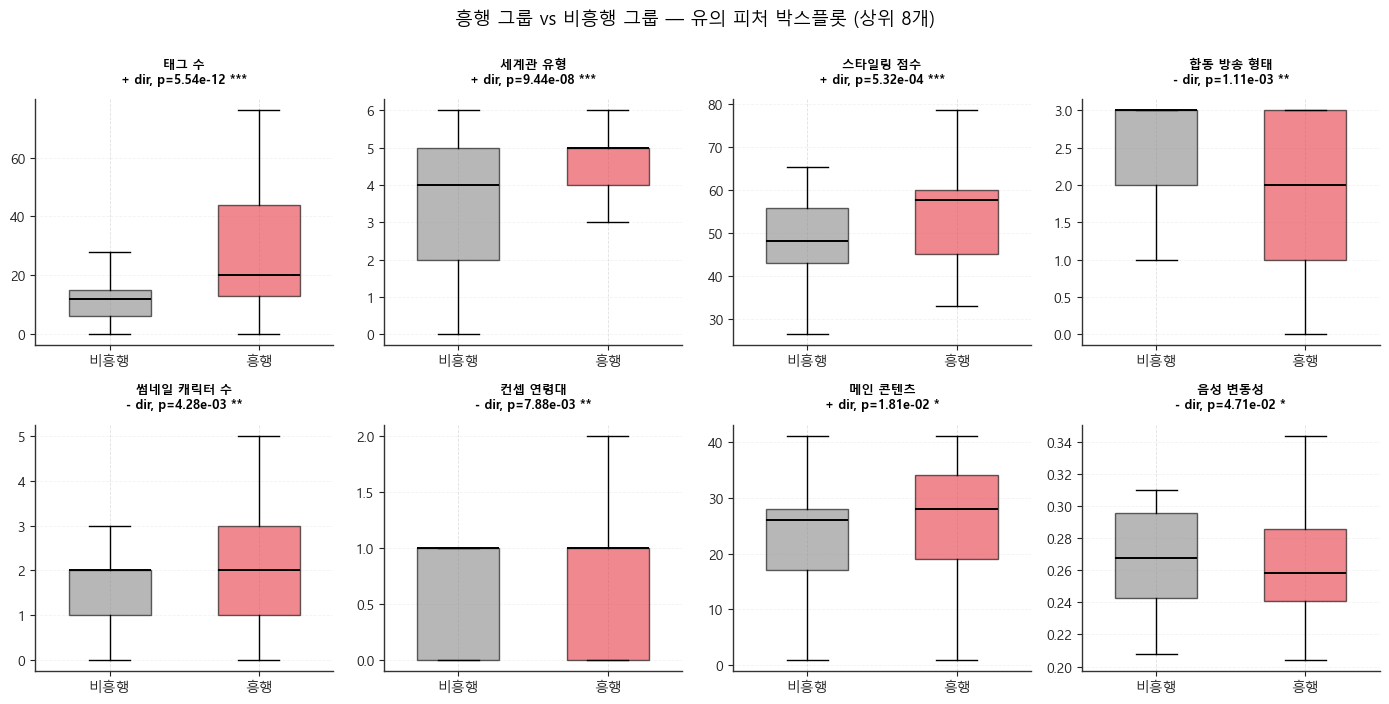

In [46]:
# (C) 흥행 그룹 vs 비흥행 그룹 분포 비교 (Mann-Whitney U 검정)
#   상·하위 20% 그룹 간 피처 분포가 통계적으로 다른지 검정해 '흥행 요소' 후보를 추린다.
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# 원본 view_count 복원
y_test_real = tt.inverse(y_test.values)

# 상위 20% = 흥행, 하위 20% = 비흥행 그룹으로 분리
high_thr = np.quantile(y_test_real, 0.80)
low_thr  = np.quantile(y_test_real, 0.20)
high_mask = y_test_real >= high_thr
low_mask  = y_test_real <= low_thr
print(f'상위 20% 컷: {high_thr:,.0f}회 (n={high_mask.sum()})')
print(f'하위 20% 컷: {low_thr:,.0f}회 (n={low_mask.sum()})')

# 채널 단위 메타 피처는 영상 흥행 요인이 아니므로 제외 (앞 SHAP 영상단위 셀의 _is_channel_meta 재사용)
analysis_cols = [c for c in X_test_fit.columns if not _is_channel_meta(c)]

# 피처별로 흥행 vs 비흥행 그룹 간 Mann-Whitney U 검정 → 중앙값·방향·p값 수집
rows = []
for col in analysis_cols:
    h = X_test_fit.loc[high_mask, col].values
    l = X_test_fit.loc[low_mask,  col].values
    if len(h) == 0 or len(l) == 0:
        continue
    try:
        u, p = stats.mannwhitneyu(h, l, alternative='two-sided')
    except Exception:
        u, p = np.nan, np.nan
    rows.append({
        'feature': col,
        'high_median': float(np.median(h)),
        'low_median':  float(np.median(l)),
        'direction': '+' if np.median(h) > np.median(l) else '-',
        'p_value': float(p),
    })

# p값 오름차순(가장 유의한 피처 먼저)으로 정리
mw_df = pd.DataFrame(rows).sort_values('p_value').reset_index(drop=True)
mw_df['feature_kr'] = mw_df['feature'].map(lambda c: RENAME_KR.get(c, c))
print('\n=== Mann-Whitney U (흥행 vs 비흥행) — p값 오름차순 ===')
print(mw_df[['feature_kr', 'high_median', 'low_median', 'direction', 'p_value']]
      .head(20).to_string(index=False))

# 시각화: 유의 피처 상위 8개 박스플롯
sig = mw_df[mw_df['p_value'] < 0.05].head(8)
n_plot = len(sig)
if n_plot == 0:
    print('\n[알림] p<0.05 유의 피처 없음 — 상위 8개 그대로 시각화')
    sig = mw_df.head(8)
    n_plot = len(sig)

# 4열 그리드에 피처별 비흥행 vs 흥행 박스플롯, 제목에 방향·p값·유의도(별표) 표기
ncols = 4
nrows = (n_plot + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5*nrows))
axes = np.atleast_2d(axes)
for i, (_, r) in enumerate(sig.iterrows()):
    ax = axes[i // ncols, i % ncols]
    col = r['feature']
    h = X_test_fit.loc[high_mask, col]
    l = X_test_fit.loc[low_mask,  col]
    bp = ax.boxplot([l, h], tick_labels=['비흥행', '흥행'],
                    patch_artist=True, widths=0.55, showfliers=False)
    for patch, c in zip(bp['boxes'], ['#888888', '#E63946']):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    for med in bp['medians']:
        med.set_color('black'); med.set_linewidth(1.4)
    star = '***' if r['p_value']<1e-3 else ('**' if r['p_value']<1e-2 else '*' if r['p_value']<5e-2 else '')
    ax.set_title(f"{r['feature_kr']}\n{r['direction']} dir, p={r['p_value']:.2e} {star}", fontsize=9)
    ax.grid(True, alpha=0.25, axis='y')
# 남는 칸 숨김
for j in range(n_plot, nrows*ncols):
    axes[j // ncols, j % ncols].axis('off')
plt.suptitle('흥행 그룹 vs 비흥행 그룹 — 유의 피처 박스플롯 (상위 8개)', fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

PDP 대상 (영상단위 FI 상위 8개): ['vtuber_styling_score', 'tag_count', 'f0_cv', 'vtuber_vibe_score', 'content_category_primary_genre', 'content_category_secondary_genre', 'vtuber_features_score', 'worldview_type']
PDP model: LightGBM (Optuna)


c:\Users\Dell5371\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning:

The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.

c:\Users\Dell5371\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning:

The column 12 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



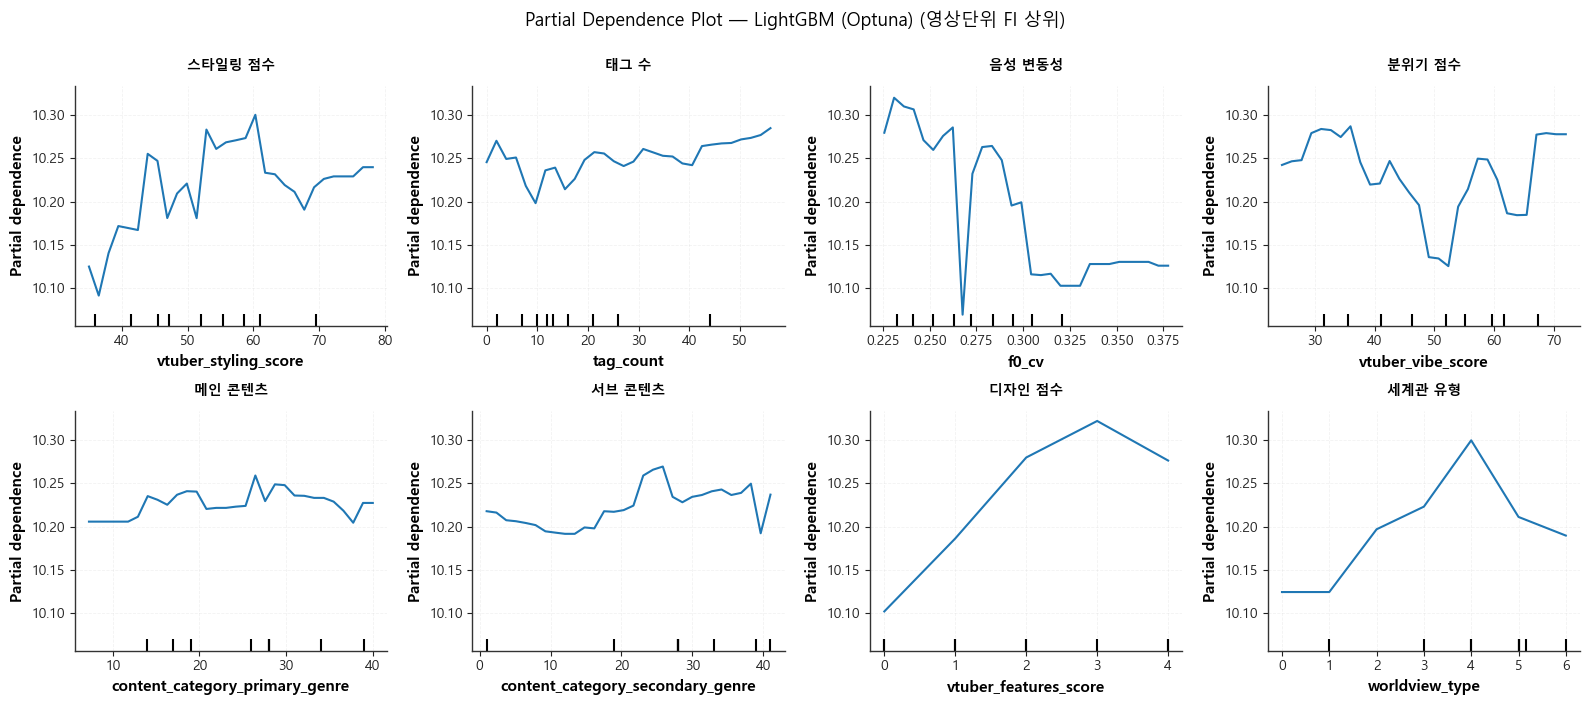

In [47]:
# (B) Partial Dependence Plot — 피처값 변화에 따른 예측 곡선
#   한 피처만 변화시켰을 때 모델 예측(view_count)이 어떻게 움직이는지 본다.
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# 영상단위 FI 상위 8개 피처 선정 (채널 메타 제외)
fi_video = fi_series[[c for c in fi_series.index if not _is_channel_meta(c)]]
top_features = fi_video.nlargest(8).index.tolist()
print(f'PDP 대상 (영상단위 FI 상위 8개): {top_features}')

# PDP 대상 모델 선택 (앙상블이면 구성 첫 모델로 대표)
pdp_name = best_combo[0] if is_ensemble else best_name
pdp_model = fitted_models[pdp_name]
print(f'PDP model: {pdp_name}')

# 모델 학습 피처 이름과 일치시킴
if hasattr(pdp_model, 'feature_name_'):
    feat_used = list(pdp_model.feature_name_)
else:
    feat_used = list(X_test_fit.columns)
X_pdp = X_test_fit[feat_used]
top_features = [c for c in top_features if c in feat_used]

# 4열 그리드에 피처별 PDP 곡선
ncols = 4
nrows = (len(top_features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5*nrows))
axes_flat = axes.ravel() if nrows > 1 else (axes if hasattr(axes, '__iter__') else [axes])
PartialDependenceDisplay.from_estimator(
    pdp_model, X_pdp, top_features,
    ax=axes_flat[:len(top_features)],
    grid_resolution=30,
    kind='average',
)
for ax, feat in zip(axes_flat[:len(top_features)], top_features):
    ax.set_title(RENAME_KR.get(feat, feat), fontsize=10)
    ax.grid(True, alpha=0.25)
# 남는 칸 숨김
for j in range(len(top_features), len(axes_flat)):
    axes_flat[j].axis('off')
plt.suptitle(f'Partial Dependence Plot — {pdp_name} (영상단위 FI 상위)', fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

Dependence 대상 (영상단위 SHAP 절대평균 상위 6): ['f0_cv', 'vtuber_features_score', 'vtuber_styling_score', 'worldview_type', 'vtuber_vibe_score', 'tag_count']


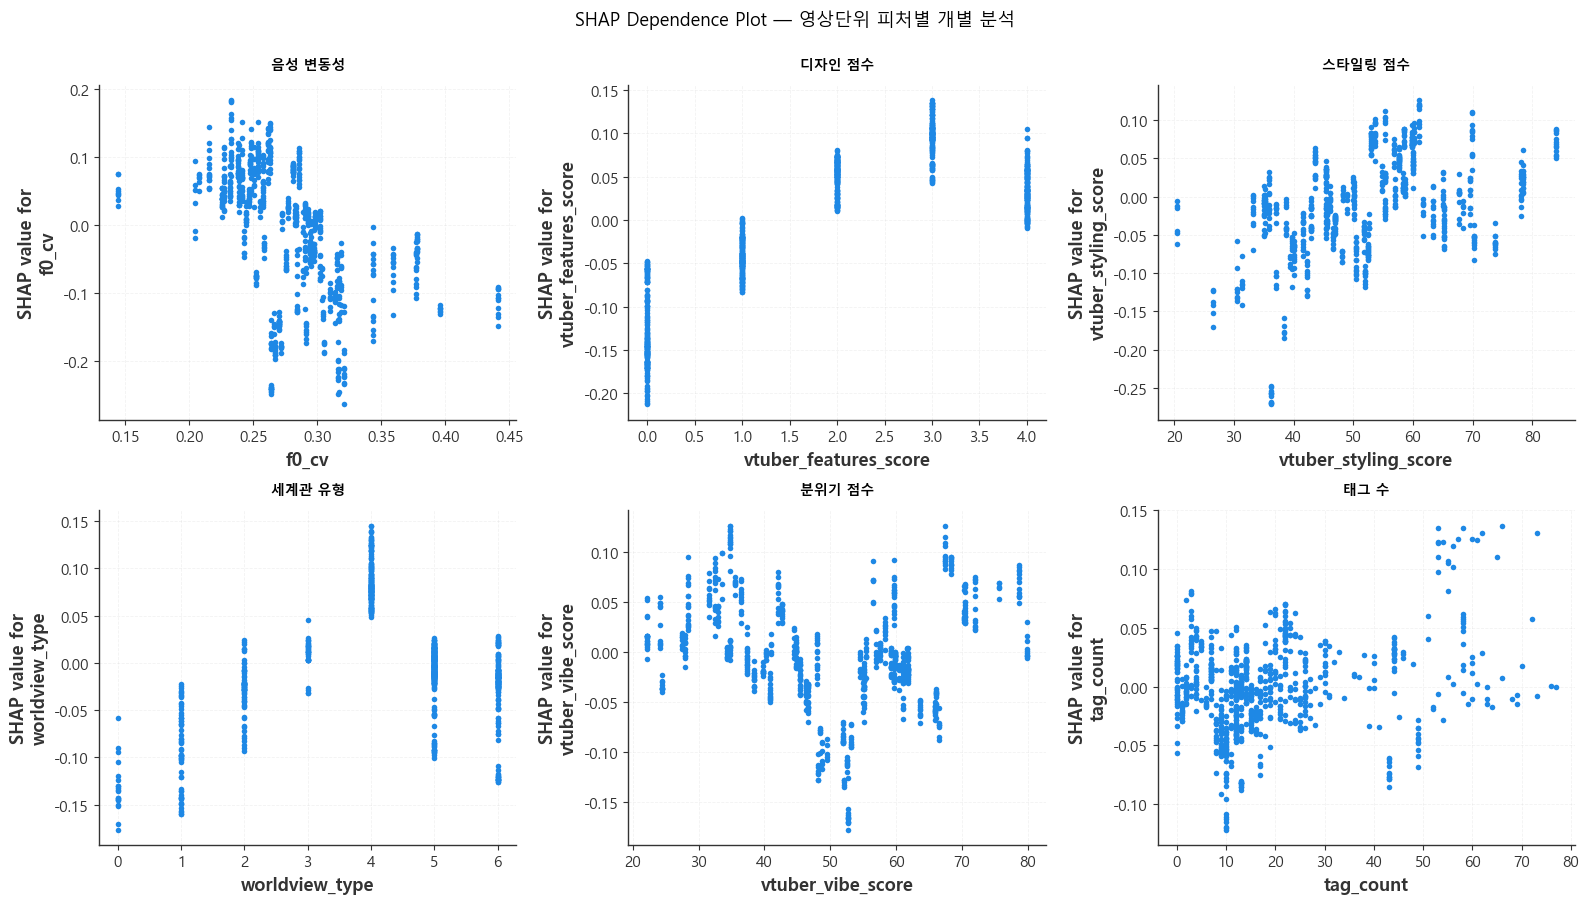

In [48]:
# (A) SHAP Dependence Plot — 피처별 개별 분석
#   피처값과 그 피처의 SHAP 기여도 관계를 산점도로 본다.
import shap
import matplotlib.pyplot as plt
import numpy as np

# 앞 SHAP 영상단위 분석 셀에서 계산한 shap_values_video / X_shap_video 재사용 (채널 메타 제외 완료)
shap_abs_mean = np.abs(shap_values_video).mean(axis=0)
top_idx = np.argsort(shap_abs_mean)[::-1][:6]
top_features = [X_shap_video.columns[i] for i in top_idx]
print(f'Dependence 대상 (영상단위 SHAP 절대평균 상위 6): {top_features}')

# SHAP 절대평균 상위 6개 피처를 2x3 그리드로
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.ravel(), top_features):
    shap.dependence_plot(
        feat, shap_values_video, X_shap_video,
        ax=ax, show=False, interaction_index=None,
    )
    ax.set_title(RENAME_KR.get(feat, feat), fontsize=10)
    ax.grid(True, alpha=0.25)
plt.suptitle('SHAP Dependence Plot — 영상단위 피처별 개별 분석', fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

## 결과 저장


In [49]:
y_test_pred = best_pred  # best 모델 예측값
# 예측 값 엑셀 변환
result_df = pd.DataFrame({
    "idx":        X_test.index,
    "video_id":   test_video_ids,
    "y_true":     tt.inverse(y_test.values),
    "y_pred":     y_test_pred,
    "residual":   tt.inverse(y_test.values) - y_test_pred,
    "abs_error":  np.abs(tt.inverse(y_test.values) - y_test_pred),
})

result_df = result_df.sort_values("abs_error", ascending=False).reset_index(drop=True)
result_df.to_excel("predictions_result.xlsx", index=False)

print(f"저장 완료: {len(result_df)}행")
result_df.head(10)

저장 완료: 797행


,idx,video_id,y_true,y_pred,residual,abs_error
0,394,Gf9RrvAd5do,127505.0,242396.398367,-114891.398367,114891.398367
1,750,v4lErQnvciw,123349.0,217391.540508,-94042.540508,94042.540508
2,749,WbcPpLee0LI,91189.0,178609.568986,-87420.568986,87420.568986
3,320,tKKyDS5lJkA,279184.0,203233.922310,75950.077690,75950.077690
4,385,KdZ1CIt8T68,134646.0,210029.041558,-75383.041558,75383.041558
5,746,hngIoesNb94,108620.0,178609.568986,-69989.568986,69989.568986
6,168,k5bmCQR5r7o,99504.0,167307.863153,-67803.863153,67803.863153
7,404,odG6vs7cFdw,90827.0,156373.252937,-65546.252937,65546.252937
8,170,RGEL2Gv_Cbw,113930.0,175710.327431,-61780.327431,61780.327431
9,261,O11mABmuUqU,81386.0,141852.552903,-60466.552903,60466.552903


In [50]:
result_df.sort_values("abs_error", ascending=False).reset_index(drop=True).head(30)

,idx,video_id,y_true,y_pred,residual,abs_error
0,394,Gf9RrvAd5do,127505.0,242396.398367,-114891.398367,114891.398367
1,750,v4lErQnvciw,123349.0,217391.540508,-94042.540508,94042.540508
2,749,WbcPpLee0LI,91189.0,178609.568986,-87420.568986,87420.568986
3,320,tKKyDS5lJkA,279184.0,203233.922310,75950.077690,75950.077690
4,385,KdZ1CIt8T68,134646.0,210029.041558,-75383.041558,75383.041558
5,746,hngIoesNb94,108620.0,178609.568986,-69989.568986,69989.568986
6,168,k5bmCQR5r7o,99504.0,167307.863153,-67803.863153,67803.863153
7,404,odG6vs7cFdw,90827.0,156373.252937,-65546.252937,65546.252937
8,170,RGEL2Gv_Cbw,113930.0,175710.327431,-61780.327431,61780.327431
9,261,O11mABmuUqU,81386.0,141852.552903,-60466.552903,60466.552903
